# Setup

In [66]:
# Import Libraries
from __future__ import annotations
import math
from typing import Callable, List, Optional, Sequence, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import Tensor
import os

We get Radial velocity measurements of the K2-24 system (EPIC 203771098), which is a CSV file from the RadVel package GitHub repository. The dataset contains 32 observations of time, radial velocity, and measurement error, and is the same dataset used in the official tutorials for the RadVel and exoplanet packages. The radial velocity measurements were collected with Keck/HIRES by the California Planet Search team and published in Petigura et al. (2016, 2018). The CSV file in the RadVel repository is the cleaned, redistributable form of that published data, and the K2-24 system is catalogued in the NASA Exoplanet Archive.

In [67]:
df = pd.read_csv('https://raw.githubusercontent.com/California-Planet-Search/radvel/master/example_data/epic203771098.csv')
df = df.drop(columns=['Unnamed: 0'])

In [68]:
df.shape # To confirm there is, in fact, 32 observations

(32, 3)

In [69]:
df.head(6) # The table has measurement error (errvel), time (t), and radial velocity (vel)

,errvel,t,vel
0,1.593725,2364.819580,6.959066
1,1.600745,2364.825101,5.017650
2,1.658815,2364.830703,13.811799
3,1.653224,2366.827579,1.151030
4,1.639095,2367.852646,9.389273
5,1.723691,2373.888150,-2.820614


Text(0, 0.5, 'radial velocity [m/s]')

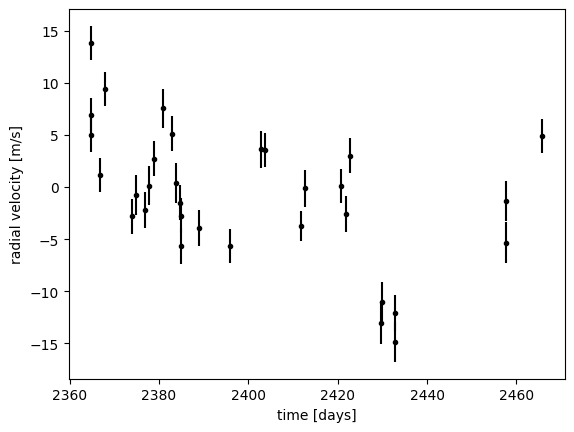

In [70]:
plt.errorbar(df.t, df.vel, yerr=df.errvel, fmt='.k')
plt.xlabel('time [days]')
plt.ylabel('radial velocity [m/s]')

# Model Setup

## Keplerian Orbit Model

The radial velocity signal from a star hosting $N_p$ planets is a sum of independent Keplerian contributions plus a systemic offset:

$$v(t) = v_0 + \sum_{j=1}^{N_p} K_j \left[ \cos\!\big(\omega_j + \nu_j(t)\big) + e_j \cos\omega_j \right]$$

For each planet $j$, the true anomaly $\nu_j(t)$ can be recovered by solving Kepler's equation. Starting from the mean anomaly given by

$$M_j(t) = \frac{2\pi}{P_j}(t - t_{p,j})$$

so we can solve

$$M_j = E_j - e_j \sin E_j$$

to get the eccentric anomaly $E_j$ using Newton iteration with the update of

$$E^{(k+1)} = E^{(k)} - \frac{E^{(k)} - e\sin E^{(k)} - M}{1 - e\cos E^{(k)}}$$

then map $E_j \to \nu_j$ via the half-angle identity given by

$$\nu_j = 2 \arctan\!\left( \sqrt{\tfrac{1+e_j}{1-e_j}} \, \tan\!\tfrac{E_j}{2} \right)$$

,implemented as an `atan2` for correct quadrant handling.

The likelihood is Gaussian with a jitter term $\sigma_J$ added in quadrature to the per-observation errors $\sigma_i$:

$$\log p(\mathbf{v} \mid \boldsymbol{\theta}) = -\tfrac{1}{2}\sum_{i=1}^{N} \left[ \frac{(v_i - v(t_i;\boldsymbol{\theta}))^2}{\sigma_i^2 + \sigma_J^2} + \log\!\big(2\pi(\sigma_i^2 + \sigma_J^2)\big) \right]$$

I chose to work in $\log\sigma_J$ so the jitter stays positive without a constrained optimizer.

The parameter vector is $\boldsymbol{\theta} = (P_1, t_{p,1}, e_1, \omega_1, K_1, P_2, t_{p,2}, e_2, \omega_2, K_2, v_0)$ with $\log\sigma_J$ tracked separately.

Implementation choices:

 Newton iteration with cap of 50 with tolerance $10^{-10}$. Eccentricity is clamped at $1 - 10^{-6}$ inside the solver to prevent the Newton denominator $1 - e\cos E$ from collapsing when $E \to 0$ and the sigmoid in the eta-reparameterization saturates in float32. The mean anomaly is wrapped into $[-\pi, \pi]$ before iteration.

*References:* Murray & Dermott, *Solar System Dynamics* (1999), Ch. 2; the standard RV inference setup follows Fulton et al. (2018) and the `radvel` package.

In [71]:
# Two-planet Keplerian radial velocity model.

@torch.compile
def solve_kepler_equation(M: Tensor, e: Tensor,
                          n_iter: int = 50, tol: float = 1e-10) -> Tensor:
    """To solve M = E - e sin(E) for the eccentric anomaly E by Newton iteration.
    M : mean anomaly (any shape), in radians.
    e : eccentricity, broadcastable with M; clamped below 1 to keep
        fp = 1 - e cos(E) from collapsing to zero when E sits near zero.
    n_iter : maximum Newton steps; we exit early once the residual is small.
    tol : convergence threshold on |E - e sin(E) - M|.
    """
    # There is a Hard cap on e: at e == 1 the Newton update divides by zero whenever
    # E lands near zero, which propagates NaNs into the flow VI gradients.
    e = e.clamp(max=1.0 - 1e-6)
    # Wraps M into [-pi, pi] so the iterates don't drift across orbital cycles.
    M = torch.remainder(M + math.pi, 2 * math.pi) - math.pi
    E = M.clone()
    for _ in range(n_iter):
        f = E - e * torch.sin(E) - M
        fp = 1.0 - e * torch.cos(E)
        E = E - f / fp
        if torch.max(torch.abs(f)) < tol:
            break
    return E


@torch.compile
def true_anomaly(M: Tensor, e: Tensor) -> Tensor:
    """To Convert mean anomaly M to true anomaly ν, given eccentricity e.
    Uses the half-angle identity in atan2 form so the quadrant is always
    correct (plain arctan would alias across discontinuities). Clamps e
    away from both bounds so sqrt(1+/-e) stays finite under autograd.
    """
    e = e.clamp(min=1e-6, max=1.0 - 1e-6)
    E = solve_kepler_equation(M, e)
    sin_half = torch.sqrt(1.0 + e) * torch.sin(E / 2.0)
    cos_half = torch.sqrt(1.0 - e) * torch.cos(E / 2.0)
    return 2.0 * torch.atan2(sin_half, cos_half)


@torch.compile
def rv_one_planet(t: Tensor, P: Tensor, tp: Tensor, e: Tensor,
                  omega: Tensor, K: Tensor) -> Tensor:
    """The RV contribution from one planet at observation times t.
    P, tp, e, omega, K : orbital period, time of periastron, eccentricity,
    argument of periastron, and semi-amplitude.
    """
    M = 2.0 * math.pi * (t - tp) / P
    nu = true_anomaly(M, e)
    return K * (torch.cos(omega + nu) + e * torch.cos(omega))


@torch.compile
def rv_model_two_planet(t: Tensor, theta: Tensor) -> Tensor:
    """The total RV from a two-planet system plus systemic offset v0.
    theta layout: [P1, tp1, e1, omega1, K1, P2, tp2, e2, omega2, K2, v0].
    Units are days for periods/tp, radians for omega, m/s for K and v0.
    """
    P1, tp1, e1, w1, K1 = theta[0], theta[1], theta[2], theta[3], theta[4]
    P2, tp2, e2, w2, K2 = theta[5], theta[6], theta[7], theta[8], theta[9]
    v0 = theta[10]
    rv1 = rv_one_planet(t, P1, tp1, e1, w1, K1)
    rv2 = rv_one_planet(t, P2, tp2, e2, w2, K2)
    return v0 + rv1 + rv2


def log_likelihood_two_planet(theta: Tensor, t: Tensor,
                              rv_obs: Tensor, rv_err: Tensor,
                              log_jitter: Tensor) -> Tensor:
    """This is the Gaussian log-likelihood with a scalar jitter added in quadrature.
    Working in log-jitter rather than jitter keeps it positive without a
    constrained optimizer; the jitter absorbs stellar activity and other
    systematics not captured in the reported per-observation error bars.
    """
    rv_pred = rv_model_two_planet(t, theta)
    sigma2 = rv_err ** 2 + torch.exp(2.0 * log_jitter)
    resid = rv_obs - rv_pred
    return -0.5 * torch.sum(resid ** 2 / sigma2 + torch.log(2.0 * math.pi * sigma2))


## Priors & Log Posterior

We will use smooth priors with no hard boundaries throughout. Variational inference samples from an unbounded Gaussian family, so any uniform prior with a sharp cutoff would return $-\infty$ gradients the moment the variational distribution crossed the boundary, ruining our optimization, so we use broad smooth priors avoid this entirely:

For Periods: Normal on log-period, weakly informative around $\log 50$ days:

$$\log P_j \sim \mathcal{N}(\log 50, \, 2^2), \quad j = 1, 2$$

For Times of periastron: Normal centered at the data midpoint:

$$t_{p,j} \sim \mathcal{N}(2400, \, 50^2)$$

For Eccentricities: Kipping (2013) empirical Beta prior, calibrated to the long-period exoplanet eccentricity distribution:

$$e_j \sim \text{Beta}(0.867, \, 3.03)$$

For Semi-amplitudes: Half-Normal on $K_j \geq 0$:

$$K_j \sim \text{HalfNormal}(50)$$

Argument of periastron: No explicit prior, so the likelihood is $2\pi$-periodic in $\omega_j$, so an improper uniform prior on $\mathbb{R}$ contributes only a constant and drops out of the unnormalized posterior.

System parameters:

$$v_0 \sim \mathcal{N}(0, 50^2), \qquad \log\sigma_J \sim \mathcal{N}(0, 2^2)$$

The unnormalized log posterior is

$$\log p(\boldsymbol{\theta}, \log\sigma_J \mid \mathbf{v}) = \log p(\mathbf{v} \mid \boldsymbol{\theta}, \log\sigma_J) + \log p(\boldsymbol{\theta}, \log\sigma_J)$$

Numerical safety: The Beta log-density `_log_beta` clamps its argument into $(10^{-6}, 1 - 10^{-6})$. An earlier implementation used `torch.where(in_range, val, -inf)` to mask out-of-support values, but that pattern leaked NaN gradients through the masked branch and breaks flow VI the moment the planar layers push the logit of $e$ into a region where the sigmoid saturates exactly to 1.0 in float32.

*References:* Kipping (2013) for the Beta prior on eccentricity; weakly informative scale priors follow Gelman et al., *Bayesian Data Analysis* (3rd ed., 2013) and Fulton et al. (2018) for Radial Velocity-specific defaults.

In [72]:
""" Note: This has smooth priors with no hard boundaries. Variational inference samples from
    an unbounded Gaussian family, so any uniform prior with a sharp cutoff would
    hand back -inf gradients the moment the variational distribution crossed
    the boundary; we use broad Normal/half-Normal/Beta priors throughout.
"""

# Period prior: Normal on log P. Mean log(50) puts the bulk of the prior mass
# between ~7 and ~370 days, generous on both sides of the K2-24 transit
# periods (21 and 42 days).
LOG_P_MEAN, LOG_P_SCALE = math.log(50.0), 2.0

# Time of periastron prior: Normal centered at the data midpoint.
TP_MEAN, TP_SCALE = 2400.0, 50.0

# Kipping (2013) empirical Beta prior on eccentricity.
KIPPING_A, KIPPING_B = 0.867, 3.03

# Semi-amplitude prior: half-Normal. K2-24 has an RV swing of about 10 m/s,
# so scale 50 is weakly informative on the positive K axis.
K_SCALE = 50.0

# Systemic velocity prior: zero-mean Gaussian.
V0_SCALE = 50.0

# Log-jitter prior: Normal centered at 0 (1 m/s a priori).
LOG_JIT_MEAN, LOG_JIT_SCALE = 0.0, 2.0


def _log_normal(x: Tensor, mean: float, scale: float) -> Tensor:
    """Log of a Normal(mean, scale^2) density evaluated at x."""
    return (-0.5 * ((x - mean) / scale) ** 2
            - math.log(scale) - 0.5 * math.log(2.0 * math.pi))


def _log_normal_log_period(P: Tensor) -> Tensor:
    """Log of the Normal-on-log-P prior, evaluated at P > 0."""
    log_P = torch.log(P.clamp(min=1e-30))
    return _log_normal(log_P, LOG_P_MEAN, LOG_P_SCALE)


def _log_beta(x: Tensor, a: float, b: float) -> Tensor:
    """Log Beta(a, b) density at x.
    This clamps x strictly inside (eps, 1-eps) so the backward pass never hits
    log(0). Earlier versions used torch.where(in_range, val, -inf), but
    that pattern leaks NaN gradients through the masked branch and kills
    flow VI as soon as the planar layers push eta to a region where
    sigmoid saturates to exactly 1.0 in float32.
    """
    eps = 1e-6
    x_safe = x.clamp(min=eps, max=1.0 - eps)
    log_norm = math.lgamma(a) + math.lgamma(b) - math.lgamma(a + b)
    return (a - 1.0) * torch.log(x_safe) + (b - 1.0) * torch.log1p(-x_safe) - log_norm


def _log_half_normal(x: Tensor, scale: float) -> Tensor:
    """Log half-Normal density on x >= 0 with the given scale."""
    in_range = x >= 0
    log_norm = 0.5 * math.log(2.0 / math.pi) - math.log(scale)
    val = log_norm - 0.5 * (x / scale) ** 2
    return torch.where(in_range, val, torch.full_like(x, float("-inf")))


def log_prior_two_planet(theta: Tensor, log_jitter: Tensor) -> Tensor:
    """This is sum of independent log-priors on the orbital parameters.
    theta : 11-vector with layout [P1, tp1, e1, w1, K1, P2, tp2, e2, w2, K2, v0].
    log_jitter : scalar log-jitter in m/s.

    Note: omega1 and omega2 carry no explicit prior: the RV likelihood
    is 2*pi periodic in omega, so an improper uniform prior on R is
    equivalent to a constant and drops out of the unnormalized posterior.
    """
    P1, tp1, e1, _w1, K1 = theta[0], theta[1], theta[2], theta[3], theta[4]
    P2, tp2, e2, _w2, K2 = theta[5], theta[6], theta[7], theta[8], theta[9]
    v0 = theta[10]

    return (
        _log_normal_log_period(P1)
        + _log_normal(tp1, TP_MEAN, TP_SCALE)
        + _log_beta(e1, KIPPING_A, KIPPING_B)
        + _log_half_normal(K1, K_SCALE)
        + _log_normal_log_period(P2)
        + _log_normal(tp2, TP_MEAN, TP_SCALE)
        + _log_beta(e2, KIPPING_A, KIPPING_B)
        + _log_half_normal(K2, K_SCALE)
        + _log_normal(v0, 0.0, V0_SCALE)
        + _log_normal(log_jitter, LOG_JIT_MEAN, LOG_JIT_SCALE)
    )


def log_posterior_two_planet(theta: Tensor, log_jitter: Tensor,
                             t: Tensor, rv_obs: Tensor, rv_err: Tensor) -> Tensor:
    """Unnormalized log posterior in the natural (constrained) parameter space."""
    return (
        log_likelihood_two_planet(theta, t, rv_obs, rv_err, log_jitter)
        + log_prior_two_planet(theta, log_jitter)
    )


## Unconstrained Reparameterization

To make the posterior geometry roughly isotropic, we need to work in a normalized parameter space $\boldsymbol{\eta} \in \mathbb{R}^{12}$ where each coordinate is approximately $\mathcal{N}(0, 1)$, centered on the K2-24 transit values. Both HMC and MALA assume a single step size applies to all coordinates; without this rescaling, $t_p$ varies on the scale of days near 2400 while $\log P$ varies on the scale of 0.1, and no single $\varepsilon$ works for both.

For the map $\boldsymbol{\eta} \to \boldsymbol{\theta}$, each coordinate transforms independently. Letting $\mu_P, \mu_{t_p}, \mu_e, \mu_K$ denote the per-coordinate centers:

$$\begin{aligned}
P_j &= \exp(\eta_{P_j} \cdot 0.3 + \mu_{P_j}) & \text{(log-scale, centered at 20.89, 42.36 d)} \\
t_{p,j} &= \eta_{tp_j} \cdot 50 + 2400 & \text{(affine)} \\
e_j &= \sigma(\eta_{e_j} \cdot 1.5 + \mu_e) & \text{(scaled logit)} \\
\omega_j &= \eta_{\omega_j} & \text{(identity)} \\
K_j &= \exp(\eta_{K_j} + \mu_{K_j}) & \text{(log-scale, centered at 8, 6 m/s)} \\
v_0 &= \eta_{v_0} \cdot 20 & \text{(affine)} \\
\log\sigma_J &= \eta_{\log J} \cdot 2 & \text{(affine)}
\end{aligned}$$

where $\sigma(x) = (1 + e^{-x})^{-1}$ is the sigmoid.

Note,the change-of-variables correction, where for HMC and MALA to target the posterior on $\boldsymbol{\eta}$, we needed

$$\log p(\boldsymbol{\eta} \mid \mathbf{v}) = \log p(\boldsymbol{\theta}(\boldsymbol{\eta}), \log\sigma_J(\boldsymbol{\eta}) \mid \mathbf{v}) + \log\left|\det \frac{\partial(\boldsymbol{\theta}, \log\sigma_J)}{\partial \boldsymbol{\eta}}\right|$$

Since the map is diagonal, the log-Jacobian is a sum of independent log-derivatives. The contribution of each coordinate depends on which variable its prior is defined over:

$$\begin{aligned}
\text{Period:} &\quad \text{prior is on } \log P, \text{ so } \log|d\log P / d\eta| = \log(0.3) \\
\text{Time of periastron:} &\quad \log|dt_p / d\eta| = \log(50) \\
\text{Eccentricity:} &\quad \log|de/d\eta| = \log(1.5) + \log e + \log(1 - e) \\
\text{Omega:} &\quad 0 \text{ (identity)} \\
\text{Semi-amplitude:} &\quad \log|dK/d\eta| = \log K = \eta_{K} + \mu_K \\
v_0: &\quad \log(20) \\
\log\sigma_J: &\quad \log(2)
\end{aligned}$$

Taking into consideration, Planet-label symmetry, the two-planet model is exactly invariant under swapping which planet is "1" and which is "2", so different chains can converge to either ordering. We resolve this post-hoc with `sort_planets_by_period`, enforcing $P_1 < P_2$ in every sample. I found this to be the standard convention in the Radial Velocity literature and this keeps all draws without discarding any.

Initialization: $\boldsymbol{\eta} = \mathbf{0}$ maps exactly to the K2 transit configuration, giving all methods the same starting point.

In [73]:
"""
Normalized reparameterization: eta ~ N(0,1) in every dimension, centered
on the K2-24 transit values (P1 = 20.89 d, P2 = 42.36 d). This makes the
posterior roughly isotropic in eta-space, which is what HMC and MALA assume
when they pick a single step size for all coordinates.
"""

# Per-coordinate centers and scales — eta = 0 puts every parameter at the
# K2 transit-derived value.
P1_LOG_MEAN,     P1_LOG_SCALE    = math.log(20.89), 0.3
P2_LOG_MEAN,     P2_LOG_SCALE    = math.log(42.36), 0.3
TP_NORM_CENTER,  TP_NORM_SCALE   = 2400.0, 50.0
E_LOGIT_MEAN,    E_LOGIT_SCALE   = math.log(0.05 / 0.95), 1.5
K1_LOG_MEAN,     K2_LOG_MEAN     = math.log(8.0), math.log(6.0)
V0_NORM_SCALE    = 20.0
LOG_JIT_NORM_SCALE = 2.0


def eta_to_theta(eta: Tensor):
    """Map normalized eta in R^12 to (theta in R^11, log_jitter scalar)."""
    P1  = torch.exp(eta[0] * P1_LOG_SCALE + P1_LOG_MEAN)
    tp1 = eta[1] * TP_NORM_SCALE + TP_NORM_CENTER
    e1  = torch.sigmoid(eta[2] * E_LOGIT_SCALE + E_LOGIT_MEAN)
    w1  = eta[3]
    K1  = torch.exp(eta[4] + K1_LOG_MEAN)

    P2  = torch.exp(eta[5] * P2_LOG_SCALE + P2_LOG_MEAN)
    tp2 = eta[6] * TP_NORM_SCALE + TP_NORM_CENTER
    e2  = torch.sigmoid(eta[7] * E_LOGIT_SCALE + E_LOGIT_MEAN)
    w2  = eta[8]
    K2  = torch.exp(eta[9] + K2_LOG_MEAN)

    v0         = eta[10] * V0_NORM_SCALE
    log_jitter = eta[11] * LOG_JIT_NORM_SCALE

    e1 = torch.clamp(e1, 0.0, 0.999)
    e2 = torch.clamp(e2, 0.0, 0.999)
    K1 = torch.clamp(K1, 0.01, 100.0)
    K2 = torch.clamp(K2, 0.01, 100.0)
    P1 = torch.clamp(P1, 1.0, 1000.0)
    P2 = torch.clamp(P2, 1.0, 1000.0)

    theta = torch.stack([P1, tp1, e1, w1, K1, P2, tp2, e2, w2, K2, v0])
    return theta, log_jitter


def log_jacobian(eta: Tensor) -> Tensor:
    """Log |det d(prior-variable) / d eta| for the change of variables.

    Per-coordinate breakdown:
      - Period: prior is on log P, so the change of variables runs from eta
        to log P. d(log P)/d eta = P_LOG_SCALE  ->  log term log(P_LOG_SCALE).
      - tp: affine in eta with slope TP_NORM_SCALE.
        log term log(TP_NORM_SCALE).
      - Eccentricity: e = sigmoid(eta * E_LOGIT_SCALE + ...).
        d e / d eta = E_LOGIT_SCALE * e * (1 - e).
        log term log(E_LOGIT_SCALE) + log(e) + log(1-e).
      - omega: identity, log term 0.
      - K: K = exp(eta + K_LOG_MEAN), so d K / d eta = K.
        log term log(K) = eta + K_LOG_MEAN.
      - v0: affine with slope V0_NORM_SCALE.
        log term log(V0_NORM_SCALE).
      - log-jitter: affine with slope LOG_JIT_NORM_SCALE.
        log term log(LOG_JIT_NORM_SCALE).
    """
    # Periods: prior on log P, Jacobian is just log(P_LOG_SCALE)
    jac = math.log(P1_LOG_SCALE) + math.log(P2_LOG_SCALE)

    # Times of periastron: affine
    jac = jac + math.log(TP_NORM_SCALE) + math.log(TP_NORM_SCALE)

    # Eccentricities: scaled logit, sigmoid derivative is e * (1-e)
    e1_logit = eta[2] * E_LOGIT_SCALE + E_LOGIT_MEAN
    e2_logit = eta[7] * E_LOGIT_SCALE + E_LOGIT_MEAN
    e1 = torch.sigmoid(e1_logit)
    e2 = torch.sigmoid(e2_logit)
    jac = jac + math.log(E_LOGIT_SCALE) + math.log(E_LOGIT_SCALE)
    jac = jac + torch.log(e1) + torch.log1p(-e1)
    jac = jac + torch.log(e2) + torch.log1p(-e2)

    # Omega: identity, contributes 0

    # Semi-amplitudes: prior is on K, Jacobian is log(K) = eta + K_LOG_MEAN
    jac = jac + (eta[4] + K1_LOG_MEAN) + (eta[9] + K2_LOG_MEAN)

    # Systemic velocity and log-jitter: affine
    jac = jac + math.log(V0_NORM_SCALE) + math.log(LOG_JIT_NORM_SCALE)

    return jac


def log_posterior_unconstrained(eta: Tensor, t: Tensor,
                                rv_obs: Tensor, rv_err: Tensor) -> Tensor:
    """Log posterior in normalized eta-space, including the Jacobian correction."""
    theta, log_jitter = eta_to_theta(eta)
    return (log_posterior_two_planet(theta, log_jitter, t, rv_obs, rv_err)
            + log_jacobian(eta))


def eta_samples_to_theta(eta_samples: Tensor) -> Tensor:
    """Convert a batch of eta samples to theta + log_jitter."""
    out_theta, out_lj = [], []
    for i in range(len(eta_samples)):
        theta, lj = eta_to_theta(eta_samples[i])
        out_theta.append(theta)
        out_lj.append(lj)
    theta_stack = torch.stack(out_theta)
    lj_stack    = torch.stack(out_lj)
    return torch.cat([theta_stack, lj_stack.unsqueeze(1)], dim=1)


def initial_eta() -> Tensor:
    """Starting point: eta = 0 maps exactly to the K2 transit configuration."""
    return torch.zeros(12)


def sort_planets_by_period(theta: Tensor) -> Tensor:
    """Enforce P1 < P2 in every row to resolve the planet-labeling symmetry."""
    out  = theta.clone()
    swap = out[:, 0] > out[:, 5]
    if swap.any():
        p1_block = out[swap, 0:5].clone()
        p2_block = out[swap, 5:10].clone()
        out[swap, 0:5] = p2_block
        out[swap, 5:10] = p1_block
    return out


## Flows

### Planar Flow

A planar normalizing flow (Rezende & Mohamed, 2015) applies a sequence of invertible transformations of the form

$$f(\mathbf{z}) = \mathbf{z} + \mathbf{u} \tanh(\mathbf{w}^\top \mathbf{z} + b)$$

where $\mathbf{u}, \mathbf{w} \in \mathbb{R}^D$ and $b \in \mathbb{R}$ are learnable parameters per layer. The log-determinant of the Jacobian has a closed form:

$$\log\left|\det \frac{\partial f}{\partial \mathbf{z}}\right| = \log\!\left| 1 + \mathbf{u}^\top \boldsymbol{\psi}(\mathbf{z}) \right|, \qquad \boldsymbol{\psi}(\mathbf{z}) = \big(1 - \tanh^2(\mathbf{w}^\top \mathbf{z} + b)\big)\, \mathbf{w}$$

This is $\mathcal{O}(D)$ to evaluate, which is an appeal of planar flows over dense Jacobian approaches, and a motivation of implementing that paper's method.

Invertibility constraint: $f$ is invertible if and only if $\mathbf{w}^\top \mathbf{u} \geq -1$ (Rezende & Mohamed, 2015, Appendix). To enforce this without a constrained optimizer, we reparameterize:

$$\hat{\mathbf{u}} = \mathbf{u} + \big[m(\mathbf{w}^\top\mathbf{u}) - \mathbf{w}^\top\mathbf{u}\big] \frac{\mathbf{w}}{\|\mathbf{w}\|^2 + \epsilon}$$

with $m(x) = -1 + \log(1 + e^x)$ a softplus shifted so $m(x) \geq -1$ for all $x$. Then $\mathbf{w}^\top \hat{\mathbf{u}} = m(\mathbf{w}^\top\mathbf{u}) \geq -1$ by construction.

Composition: Stacking $K$ planar layers $f_1, f_2, \ldots, f_K$ gives a flow whose log-density is

$$\log q_K(\mathbf{z}_K) = \log q_0(\mathbf{z}_0) - \sum_{k=1}^{K} \log\left|\det \frac{\partial f_k}{\partial \mathbf{z}_{k-1}}\right|$$

starting from a base distribution $q_0$ (we use a diagonal Gaussian).

Specific mplementation choices: Parameters initialized as $\mathbf{u}, \mathbf{w} \sim \mathcal{N}(0, 0.01^2 I)$ and $b = 0$, so each layer starts near the identity. We use $K = 8$ layers for normalization flow variational inference on this problem.

*Reference:* Rezende, D. J. & Mohamed, S. (2015), *Variational Inference with Normalizing Flows*, ICML.

In [74]:
# Planar normalizing flow used by flow-based variational inference.

class PlanarLayer(nn.Module):
    """One planar transformation f(z) = z + u * tanh(w^T z + b).
    A single planar layer is cheap (linear in the dimension D) and gives
    log-determinants in closed form. The reparameterization in u_hat() forces
    w^T u_hat >= -1 so the layer is guaranteed invertible no matter what
    the optimizer does with u and w.
    """

    def __init__(self, D: int):
        super().__init__()
        """Small init: each layer starts essentially as the identity map, which
         gives the optimizer a sane place to start."""
        self.u = nn.Parameter(torch.randn(D) * 0.01)
        self.w = nn.Parameter(torch.randn(D) * 0.01)
        self.b = nn.Parameter(torch.zeros(1))

    def u_hat(self) -> Tensor:
        """Reparameterized u that satisfies w^T u_hat >= -1."""
        wu = torch.dot(self.w, self.u)
        m_wu = -1.0 + F.softplus(wu)  # softplus(x) = log(1 + exp x)
        return self.u + (m_wu - wu) * self.w / (torch.dot(self.w, self.w) + 1e-12)

    def forward(self, z: Tensor):
        """Applys the planar map and return (f(z), log|det df/dz|).a
        z has shape (n, D); the returned tensors are (n, D) and (n,).
        """
        u_hat = self.u_hat()
        a = z @ self.w + self.b                                              # (n,)
        f_z = z + u_hat.unsqueeze(0) * torch.tanh(a).unsqueeze(1)             # (n, D)
        psi = (1.0 - torch.tanh(a) ** 2).unsqueeze(1) * self.w.unsqueeze(0)   # (n, D)
        log_det = torch.log(torch.abs(1.0 + psi @ u_hat) + 1e-12)             # (n,)
        return f_z, log_det


### Real-NVP

Real-NVP (Dinh, Sohl-Dickstein & Bengio, 2017) builds invertible transformations by coupling: a fixed binary mask $\mathbf{b} \in \{0, 1\}^D$ partitions the coordinates into two halves, and only one half is transformed conditionally on the other.

Coupling layer (forward): Given input $\mathbf{z}$:

$$\mathbf{y} = \mathbf{b} \odot \mathbf{z} + (1 - \mathbf{b}) \odot \big[ \mathbf{z} \odot \exp(s(\mathbf{b} \odot \mathbf{z})) + t(\mathbf{b} \odot \mathbf{z}) \big]$$

where $s, t : \mathbb{R}^D \to \mathbb{R}^D$ are arbitrary neural networks (no invertibility requirements) and $\odot$ is elementwise multiplication. The masked half passes through unchanged; the unmasked half receives an affine transformation whose scale and shift depend only on the masked half.

Coupling layer (inverse):

 Easily invertible:

$$\mathbf{z} = \mathbf{b} \odot \mathbf{y} + (1 - \mathbf{b}) \odot \big[ (\mathbf{y} - t(\mathbf{b} \odot \mathbf{y})) \odot \exp(-s(\mathbf{b} \odot \mathbf{y})) \big]$$

Triangular Jacobian:

Because the masked half is unchanged and the unmasked half depends only on the masked half plus itself through a diagonal scaling, the Jacobian is triangular:

$$\log\left|\det \frac{\partial \mathbf{y}}{\partial \mathbf{z}}\right| = \sum_{i : b_i = 0} s_i(\mathbf{b} \odot \mathbf{z})$$

Composition with alternating masks:

 A single coupling layer leaves half the coordinates fixed, so we stack $L$ layers and alternate which half is masked. With stripe masks $\mathbf{b}^{(k)}$ defined by $b^{(k)}_i = \mathbb{1}[i \bmod 2 = k \bmod 2]$, every coordinate gets transformed across consecutive layers.

Base distribution and density:

With base $\mathbf{z}_0 \sim \mathcal{N}(\mathbf{0}, I)$ and full forward map $T = f_L \circ \cdots \circ f_1$:

$$\log q(\mathbf{y}) = \log \mathcal{N}(T^{-1}(\mathbf{y}); \mathbf{0}, I) + \log\left|\det \frac{\partial T^{-1}}{\partial \mathbf{y}}\right|$$

Specific implementation choices:

 Each scale and shift network is a 3-layer MLP with hidden width 64 and Tanh activations. The final Linear in $s$ has Tanh applied after it to bound the scale output, which empirically stabilizes training early on (a trick used in most reference implementations). Final-layer weights are zero-initialized so each coupling layer starts as the identity transformation. We use $L = 6$ layers for flow-MCMC on this problem.

*References:* Dinh, L., Sohl-Dickstein, J. & Bengio, S. (2017), *Density Estimation Using Real NVP*, ICLR. Architecture choices follow the reference implementation released with that paper.

In [75]:
# Real-valued Non-Volume Preserving coupling-layer flow used by Normalizing Flow-Markov Chain Monte Carlo.

class CouplingLayer(nn.Module):
    """One Real-NVP coupling layer with a fixed binary mask.
    The masked half of the input is passed through unchanged; the unmasked
    half gets an affine transformation whose scale and shift are computed
    from the masked half. The Jacobian is triangular so log|det| is just
    the sum of the (1 - mask)-weighted scale outputs.
    """

    def __init__(self, D: int, mask: Tensor, hidden: int = 64):
        super().__init__()
        self.register_buffer("mask", mask)
        """Two small MLPs. The final tanh on s_net bounds the scale output,
           which empirically helps stability early in training"""
        self.s_net = nn.Sequential(
            nn.Linear(D, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden), nn.Tanh(),
            nn.Linear(hidden, D), nn.Tanh(),
        )
        self.t_net = nn.Sequential(
            nn.Linear(D, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden), nn.Tanh(),
            nn.Linear(hidden, D),
        )

        """Zero out the final Linear of each net so each layer starts as the
           identity. s_net ends with Tanh (its last Linear is at -2); t_net
           ends with Linear at -1."""
        nn.init.zeros_(self.s_net[-2].weight)
        nn.init.zeros_(self.s_net[-2].bias)
        nn.init.zeros_(self.t_net[-1].weight)
        nn.init.zeros_(self.t_net[-1].bias)

    def forward(self, z: Tensor):
        """z -> y, return (y, log|det df/dz|)."""
        z_masked = z * self.mask
        s = self.s_net(z_masked) * (1 - self.mask)
        t = self.t_net(z_masked) * (1 - self.mask)
        y = z_masked + (1 - self.mask) * (z * torch.exp(s) + t)
        return y, s.sum(dim=-1)

    def inverse(self, y: Tensor):
        """y -> z, return (z, log|det dg/dy|) where g is the inverse map."""
        y_masked = y * self.mask
        s = self.s_net(y_masked) * (1 - self.mask)
        t = self.t_net(y_masked) * (1 - self.mask)
        z = y_masked + (1 - self.mask) * ((y - t) * torch.exp(-s))
        return z, -s.sum(dim=-1)


class RealNVP(nn.Module):
    """Stacks of coupling layers with alternating-stripe masks.
    Alternating the mask each layer ensures every coordinate gets transformed.
    The base distribution is a standard isotropic Gaussian.
    """

    def __init__(self, D: int, n_layers: int = 6, hidden: int = 64):
        super().__init__()
        self.D = D
        self.layers = nn.ModuleList()
        for k in range(n_layers):
            mask = torch.zeros(D)
            mask[k % 2 :: 2] = 1.0  # alternating stripes
            self.layers.append(CouplingLayer(D, mask, hidden=hidden))

    def forward(self, z: Tensor):
        """Pushes base samples z through the flow. Returns (y, sum log|det|)."""
        log_det = torch.zeros(z.shape[0])
        for layer in self.layers:
            z, ld = layer(z)
            log_det = log_det + ld
        return z, log_det

    def inverse(self, y: Tensor):
        """Pulls y back to base samples z. Returns (z, sum log|det|)."""
        log_det = torch.zeros(y.shape[0])
        for layer in reversed(self.layers):
            y, ld = layer.inverse(y)
            log_det = log_det + ld
        return y, log_det

    def log_q(self, y: Tensor) -> Tensor:
        """Log of the pushforward density at y.
        Uses the change of variables: if z = T^{-1}(y) and rho_B = N(0, I),
        then log rho_hat(y) = log rho_B(z) + log|det dT^{-1}/dy|.
        """
        z, log_det_inv = self.inverse(y)
        log_base = (-0.5 * z ** 2 - 0.5 * math.log(2.0 * math.pi)).sum(dim=-1)
        return log_base + log_det_inv

    def sample(self, n: int):
        """Draws n samples from the pushforward distribution.
        Returns (y, log_q(y)) so the caller doesn't need a separate log_q call.
        """
        z = torch.randn(n, self.D)
        y, log_det = self.forward(z)
        log_base = (-0.5 * z ** 2 - 0.5 * math.log(2.0 * math.pi)).sum(dim=-1)
        return y, log_base - log_det


## Inference

### Hamiltonian Monte Carlo

Hamiltonian Monte Carlo (Neal, 2011; Duane et al., 1987) augments the target $\pi(\boldsymbol{\eta}) \propto e^{-U(\boldsymbol{\eta})}$ with an auxiliary momentum $\mathbf{v} \in \mathbb{R}^D$ drawn from $\mathcal{N}(\mathbf{0}, I)$, defining the joint Hamiltonian

$$H(\boldsymbol{\eta}, \mathbf{v}) = U(\boldsymbol{\eta}) + \tfrac{1}{2} \mathbf{v}^\top \mathbf{v}$$

with potential energy $U(\boldsymbol{\eta}) = -\log\pi(\boldsymbol{\eta})$. The continuous-time Hamiltonian dynamics

$$\frac{d\boldsymbol{\eta}}{dt} = \mathbf{v}, \qquad \frac{d\mathbf{v}}{dt} = -\nabla U(\boldsymbol{\eta})$$

preserve $H$ exactly and the marginal of the joint stationary distribution over $\boldsymbol{\eta}$ is $\pi$. The discrete-time approximation uses the leapfrog integrator with step size $\varepsilon$ and $L$ steps:

$$\begin{aligned}
\mathbf{v}^{(t + \varepsilon/2)} &= \mathbf{v}^{(t)} - \tfrac{\varepsilon}{2} \nabla U(\boldsymbol{\eta}^{(t)}) \\
\boldsymbol{\eta}^{(t + \varepsilon)} &= \boldsymbol{\eta}^{(t)} + \varepsilon \, \mathbf{v}^{(t + \varepsilon/2)} \\
\mathbf{v}^{(t + \varepsilon)} &= \mathbf{v}^{(t + \varepsilon/2)} - \tfrac{\varepsilon}{2} \nabla U(\boldsymbol{\eta}^{(t + \varepsilon)})
\end{aligned}$$

repeated $L$ times. The integrator is symplectic and time-reversible, but $H$ drifts at $\mathcal{O}(\varepsilon^2)$. A Metropolis correction at the end of each trajectory restores exactness:

$$\alpha = \min\!\Big(1,\; \exp\!\big[H(\boldsymbol{\eta}^{(0)}, \mathbf{v}^{(0)}) - H(\boldsymbol{\eta}^{(L)}, \mathbf{v}^{(L)})\big]\Big)$$

We accept the proposal $\boldsymbol{\eta}^{(L)}$ with probability $\alpha$. Negating the final momentum makes the proposal map an involution (Neal, 2011), which simplifies the reversibility argument.

About the Implementation choices:
- Step size $\varepsilon = 0.01$, tuned to give acceptance rates in the healthy $0.65$–$0.85$ range. Lower values push acceptance up but waste compute; higher values cause leapfrog to overshoot in high-curvature regions.
- Leapfrog steps $L = 30$, giving a trajectory length of $L\varepsilon = 0.3$ in normalized $\boldsymbol{\eta}$-space. Shorter than the theoretical optimum (~$1$ unit) but represents a reasonable compromise: each HMC step costs $L$ gradient evaluations.
- Multi-chain: 12 chains × 500 samples × 300 burnin = 6000 total draws. The proposal feedback for this project specified that the number of chains should be at least as large as the number of expected modes; K2-24 has period-aliasing modes at $1$-day and $2$:$1$ resonance harmonics, motivating $\geq 8$ chains.
- Each chain seeded independently (`torch.manual_seed(chain_id)`) for reproducibility.

*References:* Neal, R. M. (2011), *MCMC Using Hamiltonian Dynamics*, in *Handbook of Markov Chain Monte Carlo*; Duane, S. et al. (1987), *Hybrid Monte Carlo*, *Physics Letters B*. The acceptance-rate tuning heuristic follows Beskos et al. (2013).

In [76]:
# Hamiltonian Monte Carlo with leapfrog integration.

def potential_and_grad(eta: Tensor,
                       log_post_fn: Callable[[Tensor], Tensor]) -> Tuple[Tensor, Tensor]:
    """Computes U(eta) = -log pi(eta) and its gradient via autograd.
    log_post_fn must be differentiable in eta. We detach at the end so the
    returned tensors don't carry the autograd graph forward.
    """
    eta = eta.detach().clone().requires_grad_(True)
    U = -log_post_fn(eta)
    grad = torch.autograd.grad(U, eta)[0]
    return U.detach(), grad.detach()


def hmc_step(eta_current: Tensor,
             log_post_fn: Callable[[Tensor], Tensor],
             epsilon: float, L: int) -> Tuple[Tensor, bool, float]:
    """One HMC transition: sample momentum, leapfrog L steps, Metropolis-correct.
    Returns (new_state, accepted, U_value). The momentum negation at the end
    of the integrator doesn't affect acceptance but makes the proposal map
    an involution, which is standard.
    """
    eta = eta_current.detach().clone()
    v = torch.randn_like(eta)
    U_curr, grad_curr = potential_and_grad(eta, log_post_fn)
    K_curr = 0.5 * torch.sum(v ** 2)

    # Leapfrog integration
    eta_new = eta.clone()
    v_new = v - 0.5 * epsilon * grad_curr

    grad_new = grad_curr.clone()
    for j in range(L):
        eta_new = eta_new + epsilon * v_new
        U_new, grad_new = potential_and_grad(eta_new, log_post_fn)
        if j != L - 1:
            v_new = v_new - epsilon * grad_new

    v_new = v_new - 0.5 * epsilon * grad_new
    v_new = -v_new  # Flip momentum for reversibility

    K_new = 0.5 * torch.sum(v_new ** 2)
    log_alpha = U_curr + K_curr - U_new - K_new

    if torch.log(torch.rand(())) < log_alpha:
        return eta_new.detach(), True, float(U_new)
    return eta_current.detach(), False, float(U_curr)


def run_hmc_chain(eta_init: Tensor,
                  log_post_fn: Callable[[Tensor], Tensor],
                  n_samples: int, epsilon: float, L: int,
                  n_burnin: int = 500,
                  chain_id: Optional[int] = None,
                  verbose: bool = False) -> Tuple[Tensor, float]:
    """Runs a single HMC chain and return (samples, accept_rate).
    Burn-in samples are not stored; they're just for the chain to forget
    its initial point.
    """
    eta = eta_init.detach().clone()

    # Burn-in phase
    for i in range(n_burnin):
        eta, accepted, U_val = hmc_step(eta, log_post_fn, epsilon, L)

    # Sampling phase
    samples = torch.empty((n_samples, eta.numel()))
    n_accept = 0

    for i in range(n_samples):
        eta, accepted, U_val = hmc_step(eta, log_post_fn, epsilon, L)
        samples[i] = eta
        n_accept += int(accepted)

    accept_rate = n_accept / n_samples

    if verbose:
        tag = f"Chain {chain_id}" if chain_id is not None else "Chain"
        print(f"{tag}: acceptance = {accept_rate:.3f}")

    return samples, accept_rate


def run_hmc_multichain(eta_init: Tensor,
                       log_post_fn: Callable[[Tensor], Tensor],
                       n_chains: int, n_samples: int,
                       epsilon: float, L: int, n_burnin: int = 500,
                       verbose: bool = True) -> Tuple[list, list]:
    """Runs n_chains independent HMC chains and return per-chain results.
    Each chain gets its own random seed and starts at the same eta_init.
    Caller is responsible for combining and label-sorting the chains.
    """
    all_samples = []
    all_accept_rates = []
    for chain_id in range(1, n_chains + 1):
        torch.manual_seed(chain_id)
        samples, acc = run_hmc_chain(
            eta_init, log_post_fn,
            n_samples=n_samples, epsilon=epsilon, L=L,
            n_burnin=n_burnin, chain_id=chain_id, verbose=verbose,
        )
        all_samples.append(samples)
        all_accept_rates.append(acc)
    return all_samples, all_accept_rates

### Mean-Field Variational Inference

Variational inference (Jordan et al., 1999; Blei et al., 2017) approximates the posterior by selecting the closest member of a chosen family $\mathcal{Q}$ in reverse KL divergence:

$$q^* = \arg\min_{q \in \mathcal{Q}}\, \mathrm{KL}\!\big(q(\boldsymbol{\eta}) \,\big\|\, p(\boldsymbol{\eta} \mid \mathbf{v})\big)$$

Equivalently, we maximize the evidence lower bound (ELBO):

$$\mathcal{L}(q) = \mathbb{E}_{q(\boldsymbol{\eta})}\!\big[\log p(\boldsymbol{\eta}, \mathbf{v}) - \log q(\boldsymbol{\eta})\big]$$

Mean-field VI restricts $\mathcal{Q}$ to fully factorized Gaussians:

$$q(\boldsymbol{\eta}) = \prod_{i=1}^{D} \mathcal{N}(\eta_i; \mu_i, s_i^2)$$

with learnable means $\boldsymbol{\mu}$ and scales $s_i = \exp(\rho_i)$ parameterized through unconstrained $\boldsymbol{\rho}$. The Gaussian entropy is available in closed form:

$$\mathbb{H}[q] = \sum_{i=1}^{D} \rho_i + \tfrac{D}{2}\big(1 + \log 2\pi\big)$$

so the ELBO reduces to

$$\mathcal{L}(\boldsymbol{\mu}, \boldsymbol{\rho}) = \mathbb{E}_{q}\big[\log p(\boldsymbol{\eta}, \mathbf{v})\big] + \mathbb{H}[q]$$

Reparameterization trick used:

 To take stochastic gradients, we write $\boldsymbol{\eta} = \boldsymbol{\mu} + \mathbf{s} \odot \boldsymbol{\epsilon}$ with $\boldsymbol{\epsilon} \sim \mathcal{N}(\mathbf{0}, I)$ (Kingma & Welling, 2014), then Monte Carlo estimate:

$$\hat{\mathcal{L}}(\boldsymbol{\mu}, \boldsymbol{\rho}) = \frac{1}{S} \sum_{s=1}^{S} \log p(\boldsymbol{\mu} + \mathbf{s} \odot \boldsymbol{\epsilon}^{(s)}, \mathbf{v}) + \mathbb{H}[q]$$

with gradients flowing through the sample.

Specific Implementation choices:


- Initialization: $\boldsymbol{\mu} = \mathbf{0}$ (K2 transit configuration in $\boldsymbol{\eta}$-space), $\rho_i = -3$ giving $s_i \approx 0.05$. A tight initial variance keeps the likelihood gradient dominant early so the variance has time to expand after the mean settles; loose initial variances cause the variance to blow up before the mean has moved.
- Optimizer: Adam at learning rate $10^{-2}$ with cosine decay to $10^{-4}$.
- Iterations: $2000$ for the individual test, $5000$ in the cross-method run (mean-field VI converges by iteration $\sim 400$, so additional iterations are wasted but harmless).
- Monte Carlo samples per ELBO step: $S = 64$.
- Gradient clipping at norm $5$ to handle occasional outlier ELBO estimates.

*References:* Jordan, M. I. et al. (1999), *An Introduction to Variational Methods for Graphical Models*; Blei, D. M., Kucukelbir, A. & McAuliffe, J. D. (2017), *Variational Inference: A Review for Statisticians*, JASA; Kingma, D. P. & Welling, M. (2014), *Auto-Encoding Variational Bayes*, ICLR.

In [77]:
# Mean-field Gaussian variational inference.

def gaussian_entropy(log_s: Tensor) -> Tensor:
    """Entropy of N(mu, diag(s^2)). Independent of mu."""
    return torch.sum(log_s) + 0.5 * log_s.numel() * (1.0 + math.log(2.0 * math.pi))


def elbo_meanfield(mu: Tensor, log_s: Tensor,
                   log_post_fn: Callable[[Tensor], Tensor],
                   n_mc: int = 32) -> Tensor:
    """Monte Carlo ELBO using the reparameterization trick.
    Draws n_mc samples eta = mu + s * eps with eps ~ N(0,I), averages
    log pi(eta), then adds the closed-form Gaussian entropy.
    """
    s = torch.exp(log_s)
    eps = torch.randn(n_mc, mu.numel())
    eta_samples = mu.unsqueeze(0) + s.unsqueeze(0) * eps
    log_pi = torch.stack([log_post_fn(eta_samples[i]) for i in range(n_mc)])
    return log_pi.mean() + gaussian_entropy(log_s)


def fit_meanfield(eta_init: Tensor,
                  log_post_fn: Callable[[Tensor], Tensor],
                  n_iter: int = 2000, lr: float = 1e-2,
                  n_mc: int = 64, log_s_init: float = -3.0,
                  verbose: bool = False) -> Tuple[Tensor, Tensor, list]:
    """Optimizes the ELBO with Adam plus cosine LR decay.
    A tight initial variance (log_s = -3, so s ~ 0.05) keeps the likelihood
    gradient dominant early and prevents the variance from blowing up before
    the mean has had a chance to settle. Cosine decay smooths out late
    training where MC noise would otherwise produce visible ELBO jitter.
    """
    mu = eta_init.detach().clone().requires_grad_(True)
    log_s = torch.full_like(eta_init, log_s_init).requires_grad_(True)

    opt = torch.optim.Adam([mu, log_s], lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        opt, T_max=n_iter, eta_min=lr * 1e-2,
    )

    history = []
    for it in range(n_iter):
        opt.zero_grad()
        elbo = elbo_meanfield(mu, log_s, log_post_fn, n_mc=n_mc)
        if torch.isnan(elbo):
            print(f"  NaN at iter {it}; aborting")
            break
        loss = -elbo
        loss.backward()
        # Clip rare large gradients that would otherwise destabilize training.
        torch.nn.utils.clip_grad_norm_([mu, log_s], 5.0)
        opt.step()
        scheduler.step()
        history.append(float(elbo.detach()))
        if verbose and (it + 1) % 200 == 0:
            print(f"iter {it+1:5d}  ELBO = {float(elbo.detach()):.2f}")

    return mu.detach(), log_s.detach(), history


def sample_meanfield(mu: Tensor, log_s: Tensor, n: int) -> Tensor:
    """Draws n samples from the fitted Gaussian variational distribution."""
    s = torch.exp(log_s)
    eps = torch.randn(n, mu.numel())
    return mu.unsqueeze(0) + s.unsqueeze(0) * eps


### Flow-Based Variational Inference

Flow-based variational inference (Rezende & Mohamed, 2015) extends mean-field VI by enriching the variational family $\mathcal{Q}$ with normalizing flows. Starting from a base sample $\boldsymbol{\eta}_0 \sim q_0$ (we use a diagonal Gaussian, same as mean-field), the flow applies $K$ invertible transformations:

$$\boldsymbol{\eta}_K = f_K \circ f_{K-1} \circ \cdots \circ f_1(\boldsymbol{\eta}_0)$$

By the change-of-variables formula, the density of $\boldsymbol{\eta}_K$ is

$$\log q_K(\boldsymbol{\eta}_K) = \log q_0(\boldsymbol{\eta}_0) - \sum_{k=1}^{K} \log\left|\det \frac{\partial f_k}{\partial \boldsymbol{\eta}_{k-1}}\right|$$

For planar layers $f_k(\mathbf{z}) = \mathbf{z} + \hat{\mathbf{u}}_k \tanh(\mathbf{w}_k^\top \mathbf{z} + b_k)$ each log-determinant is $\mathcal{O}(D)$.

The flow ELBO substitutes this richer density into the same objective:

$$\mathcal{L}_K = \mathbb{E}_{q_0(\boldsymbol{\eta}_0)}\!\left[\log p(\boldsymbol{\eta}_K, \mathbf{v}) - \log q_0(\boldsymbol{\eta}_0) + \sum_{k=1}^{K} \log\left|\det \frac{\partial f_k}{\partial \boldsymbol{\eta}_{k-1}}\right|\right]$$

The Monte Carlo estimator pulls samples through the flow and accumulates the log-Jacobian terms during the forward pass.

Why normalization flow variational inference can beat mean-field variation inference:

A diagonal Gaussian cannot represent posterior correlations between coordinates; the flow's transformations introduce these correlations through the non-linearity of each $\tanh$. Rezende & Mohamed (2015) prove that with sufficient depth, planar flows are universal approximators in the limit, though for moderate $K$ they remain *local* deformations of the base Gaussian, they cannot easily span well-separated modes (so we confirm this in the analysis cells below)

On Implementation choices I made:

- $K = 8$ planar layers, each initialized near the identity ($\mathbf{u}, \mathbf{w}$ small Gaussian, $b = 0$).
- Base distribution: diagonal Gaussian with $\boldsymbol{\mu} = \mathbf{0}$, $\rho_i = -3$ matching mean-field VI.
- Adam optimizer with learning rate $10^{-3}$ (one decade smaller than mean-field; planar layers compose gradients across $K$ layers so the safe step size shrinks).
- Cosine decay schedule down to $10^{-5}$.
- Iterations: $2000$ for individual test, $5000$ in cross-method. Flow VI converges much more slowly than mean-field VI because it has more parameters to optimize; at $2000$ iterations it is still actively improving.
- Monte Carlo samples per ELBO: $S = 32$ (half of mean-field VI, because each sample requires a forward pass through the flow).
- Gradient clipping at norm $10$.

*Reference:* Rezende, D. J. & Mohamed, S. (2015), *Variational Inference with Normalizing Flows*, ICML.

In [78]:
# Variational inference with planar normalizing flows.

class FlowVI(nn.Module):
    """Mean-field Gaussian base distribution + K planar transformations.
    Sampling pushes a reparameterized Gaussian draw through the K layers in
    sequence; the log-density of each sample is tracked alongside by
    subtracting the per-layer log|det Jacobian|.
    """

    def __init__(self, D: int, K: int,
                 mu_init: Optional[Tensor] = None,
                 log_s_init: float = -3.0):
        super().__init__()
        if mu_init is None:
            mu_init = torch.zeros(D)
        self.mu = nn.Parameter(mu_init.clone())
        self.log_s = nn.Parameter(torch.full((D,), log_s_init))
        self.layers = nn.ModuleList([PlanarLayer(D) for _ in range(K)])

    def sample_and_log_q(self, n: int) -> Tuple[Tensor, Tensor]:
        """Draw n samples from the flow and return (samples, log q at samples)."""
        eps = torch.randn(n, self.mu.numel())
        s = torch.exp(self.log_s)
        z = self.mu.unsqueeze(0) + s.unsqueeze(0) * eps
        # log q_0 of the diagonal Gaussian base, written via eps so we
        # don't have to invert the reparam map.
        log_q = (-0.5 * eps ** 2 - self.log_s - 0.5 * math.log(2.0 * math.pi)).sum(dim=1)
        for layer in self.layers:
            z, log_det = layer(z)
            log_q = log_q - log_det
        return z, log_q


def fit_flow_vi(model: FlowVI,
                log_post_fn: Callable[[Tensor], Tensor],
                n_iter: int = 2000, lr: float = 1e-3,
                n_mc: int = 32, verbose: bool = False) -> list:
    """Trains a FlowVI model by maximizing the flow-based ELBO.
    The learning rate is lower than mean-field VI (1e-3 vs 1e-2): planar
    layers compose gradients across K layers, so the safe step size shrinks.
    Cosine LR decay and a gentle norm clip at 10 keep training stable
    without strangling the flow.
    """
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        opt, T_max=n_iter, eta_min=lr * 1e-2,
    )

    history = []
    for it in range(n_iter):
        opt.zero_grad()
        z, log_q = model.sample_and_log_q(n_mc)

        if torch.isnan(z).any() or torch.isnan(log_q).any():
            print(f"  NaN in flow output at iter {it}; aborting")
            break

        log_pi = torch.stack([log_post_fn(z[i]) for i in range(n_mc)])
        if torch.isnan(log_pi).any():
            bad = int(torch.isnan(log_pi).nonzero()[0, 0])
            print(f"  NaN in log_pi at iter {it}, sample {bad}: z = {z[bad].tolist()}")
            break

        elbo = (log_pi - log_q).mean()
        loss = -elbo
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 10.0)
        opt.step()
        scheduler.step()
        history.append(float(elbo.detach()))

        if verbose and (it + 1) % 200 == 0:
            print(f"iter {it+1:5d}  ELBO = {float(elbo):.2f}")

    return history


### FlowMC

Adaptive MCMC augmented with normalizing flows (Gabrié, Rotskoff & Vanden-Eijnden, 2022) combines two MCMC kernels and trains a normalizing flow concurrently on the chain history. Each "outer iteration" applies a compounded kernel that alternates local and global moves.

Local kernel: MALA: Metropolis-adjusted Langevin (Roberts & Tweedie, 1996) proposes

$$\boldsymbol{\eta}' = \boldsymbol{\eta} + \tfrac{\tau}{2} \nabla \log\pi(\boldsymbol{\eta}) + \sqrt{\tau}\, \boldsymbol{\xi}, \quad \boldsymbol{\xi} \sim \mathcal{N}(\mathbf{0}, I)$$

accepted with Metropolis ratio

$$\alpha_{\text{loc}} = \min\!\left(1,\; \frac{\pi(\boldsymbol{\eta}') \, q(\boldsymbol{\eta} \mid \boldsymbol{\eta}')}{\pi(\boldsymbol{\eta}) \, q(\boldsymbol{\eta}' \mid \boldsymbol{\eta})}\right)$$

where $q(\cdot \mid \boldsymbol{\eta})$ is the Gaussian proposal with mean $\boldsymbol{\eta} + \tfrac{\tau}{2}\nabla\log\pi(\boldsymbol{\eta})$ and covariance $\tau I$.

Global kernel:

flow-based independence MH. With flow $T_\phi$ pushing $\mathcal{N}(\mathbf{0}, I)$ to a learned distribution $\hat{\rho}_\phi$:

$$\boldsymbol{\eta}' \sim \hat{\rho}_\phi, \qquad \alpha_{\text{glob}} = \min\!\left(1,\; \frac{\pi(\boldsymbol{\eta}') \, \hat{\rho}_\phi(\boldsymbol{\eta})}{\pi(\boldsymbol{\eta}) \, \hat{\rho}_\phi(\boldsymbol{\eta}')}\right)$$

When $\hat{\rho}_\phi \approx \pi$, $\alpha_{\text{glob}}$ stays close to 1 and the kernel makes *non-local* jumps between modes that MALA cannot reach.

Adaptive flow training:

 The flow is trained on the chain history by maximizing the log-likelihood of accumulated chain states (equivalently, minimizing forward KL):

$$\phi^* = \arg\max_\phi\, \frac{1}{|\mathcal{B}|} \sum_{\boldsymbol{\eta} \in \mathcal{B}} \log \hat{\rho}_\phi(\boldsymbol{\eta})$$

where $\mathcal{B}$ is a rolling buffer of the last $B$ chain states across all chains. Adaptation runs in parallel with sampling: each outer iteration takes one Adam step on the flow loss.

Algorithm 1 (Gabrié et al., 2022), per outer iteration:
1. Each chain runs $n_{\text{local}}$ MALA steps.
2. After a warmup period, each chain attempts one flow-based independence MH proposal.
3. Append current chain states to the rolling buffer.
4. Take one Adam step on the flow's negative log-likelihood against the buffer.

Why did I use a warmup: I did this because early in sampling, the flow has been trained on very narrow chain regions and may propose far from the typical set, hurting the acceptance. The MALA-only warmup lets chains equilibrate before global proposals begin.

Implementation choices made:
- Local proposal: $\tau = 5 \times 10^{-4}$, tuned to achieve local acceptance in the $0.3$–$0.5$ range. Smaller than the project's earlier $10^{-3}$ setting; the smaller step gives higher acceptance in high-curvature regions of the posterior.
- $n_{\text{local}} = 5$ MALA steps per outer iteration per chain.
- $24$ parallel chains, initialized at $\boldsymbol{\eta} = \mathbf{0}$ plus $\mathcal{N}(\mathbf{0}, 0.01^2 I)$ jitter. More chains than HMC because flow training benefits from diverse training data; this is the design feature the paper emphasizes.
- Flow architecture: $L = 6$ Real-NVP coupling layers with hidden width $64$.
- Flow optimizer: Adam at learning rate $5 \times 10^{-3}$.
- Buffer size: $B = 2000$ chain states (rolling FIFO).
- Warmup: $50$ outer iterations of MALA-only, then global proposals begin.
- Outer iterations: $600$ total, gradient clipping at norm $5$ on flow updates.
- Burn-in: discard the first $1/4$ of saved chain states before computing posterior summaries.

*References:* Gabrié, M., Rotskoff, G. M. & Vanden-Eijnden, E. (2022), *Adaptive Monte Carlo augmented with normalizing flows*, PNAS. The MALA scheme follows Roberts, G. O. & Tweedie, R. L. (1996), *Bernoulli*.

In [79]:
# Adaptive Markov Chain Monte Carlo augmented with normalizing flows.

def log_post_and_grad(eta: Tensor,
                      log_post_fn: Callable[[Tensor], Tensor]) -> Tuple[Tensor, Tensor]:
    """log pi(eta) and its gradient. MALA needs grad log pi directly, not -grad U."""
    eta = eta.detach().clone().requires_grad_(True)
    log_pi = log_post_fn(eta)
    grad = torch.autograd.grad(log_pi, eta)[0]
    return log_pi.detach(), grad.detach()


def mala_step(eta: Tensor,
              log_post_fn: Callable[[Tensor], Tensor],
              tau: float) -> Tuple[Tensor, bool]:
    """One Metropolis-adjusted Langevin step.
    Proposal: y = x + (tau/2) grad log pi(x) + sqrt(tau) * N(0,I).
    Acceptance: MH ratio that accounts for the asymmetric proposal density.
    """
    eta = eta.detach().clone()
    log_pi_curr, grad_curr = log_post_and_grad(eta, log_post_fn)
    mu_fwd = eta + 0.5 * tau * grad_curr
    eta_prop = mu_fwd + math.sqrt(tau) * torch.randn_like(eta)
    log_pi_prop, grad_prop = log_post_and_grad(eta_prop, log_post_fn)
    mu_back = eta_prop + 0.5 * tau * grad_prop
    log_q_fwd = -0.5 * torch.sum((eta_prop - mu_fwd) ** 2) / tau
    log_q_back = -0.5 * torch.sum((eta - mu_back) ** 2) / tau
    log_alpha = (log_pi_prop - log_pi_curr) + (log_q_back - log_q_fwd)
    if torch.log(torch.rand(())) < log_alpha:
        return eta_prop.detach(), True
    return eta.detach(), False


def flow_proposal_step(eta: Tensor,
                       log_post_fn: Callable[[Tensor], Tensor],
                       flow: RealNVP) -> Tuple[Tensor, bool]:
    """Independence MH step using the flow as the proposal distribution.
    Draws y from the flow's pushforward, evaluates the flow density at both
    the current state x and the proposal y, then accepts with the ratio
    pi(y) * rho_hat(x) / (pi(x) * rho_hat(y)). When the flow is well-tuned
    to the target, this proposal makes long, non-local jumps between modes
    that local MALA cannot reach.
    """
    with torch.no_grad():
        log_pi_curr = log_post_fn(eta)
        log_q_curr = flow.log_q(eta.unsqueeze(0))[0]
        z = torch.randn(1, flow.D)
        y, log_det = flow.forward(z)
        log_base = (-0.5 * z ** 2 - 0.5 * math.log(2.0 * math.pi)).sum(dim=-1)
        log_q_prop = log_base - log_det
    log_pi_prop = log_post_fn(y[0])
    log_alpha = (log_pi_prop - log_pi_curr) + (log_q_curr - log_q_prop[0])
    if torch.log(torch.rand(())) < log_alpha:
        return y[0].detach(), True
    return eta.detach(), False


def run_flowmc(eta_inits: Tensor,
               log_post_fn: Callable[[Tensor], Tensor],
               flow: RealNVP,
               n_iter: int, mala_tau: float,
               n_local_per_global: int = 5,
               lr: float = 5e-3,
               flow_warmup: int = 20,
               buffer_size: int = 2000,
               verbose: bool = False):
    """Adaptive flow-MCMC. Each outer iteration:

    1. n_local_per_global MALA sweeps per chain (local within-mode exploration).
    2. After flow_warmup outer steps, one flow proposal per chain.
    3. One Adam step on the flow's negative-log-likelihood loss against the
       last buffer_size chain states. The buffer is a rolling FIFO that
       smooths the training signal compared to using only the current state.

    Returns the full per-step chain history, the flow loss history, and the
    cumulative MALA / flow acceptance rates.
    """
    n_chains = eta_inits.shape[0]
    chains = eta_inits.detach().clone()
    opt = torch.optim.Adam(flow.parameters(), lr=lr)
    history = []
    saved = []
    buffer = []
    n_loc_acc = n_loc_try = 0
    n_glob_acc = n_glob_try = 0

    for step in range(n_iter):
        # Local MALA sweeps
        for _ in range(n_local_per_global):
            for c in range(n_chains):
                chains[c], a = mala_step(chains[c], log_post_fn, mala_tau)
                n_loc_acc += int(a); n_loc_try += 1
        # Global flow proposals after the warmup
        if step >= flow_warmup:
            for c in range(n_chains):
                chains[c], a = flow_proposal_step(chains[c], log_post_fn, flow)
                n_glob_acc += int(a); n_glob_try += 1
        # Appends to the training buffer (rolling FIFO)
        buffer.append(chains.detach().clone())
        if len(buffer) * n_chains > buffer_size:
            buffer.pop(0)
        train_batch = torch.cat(buffer, dim=0)
        # One gradient step on the flow loss (negative log-likelihood of buffer)
        opt.zero_grad()
        loss = -flow.log_q(train_batch).mean()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(flow.parameters(), 5.0)
        opt.step()

        history.append(float(loss.detach()))
        saved.append(chains.detach().clone())

        if verbose and (step + 1) % 50 == 0:
            la = n_loc_acc / max(1, n_loc_try)
            ga = n_glob_acc / max(1, n_glob_try)
            print(f"step {step+1:4d}  loss = {float(loss):.2f}  "
                  f"local acc = {la:.2f}  global acc = {ga:.2f}")

    return (torch.stack(saved), history,
            n_loc_acc / max(1, n_loc_try),
            n_glob_acc / max(1, n_glob_try))


# Analysis

## Diagnostics

Autocorrelation:
 For a 1D chain $x_1, x_2, \ldots, x_N$ with sample mean $\bar{x}$, the lag-$k$ autocorrelation is

$$\hat{\rho}_k = \frac{1}{(N-k) \hat{\sigma}^2} \sum_{i=1}^{N-k} (x_i - \bar{x})(x_{i+k} - \bar{x}), \quad \hat{\sigma}^2 = \frac{1}{N}\sum_{i=1}^{N} (x_i - \bar{x})^2$$

Effective sample size: The integrated autocorrelation time $\tau_{\text{int}}$ measures how many MCMC iterations effectively count as one independent sample:

$$\tau_{\text{int}} = 1 + 2 \sum_{k=1}^{\infty} \rho_k$$

Truncating at the first negative-autocorrelation lag (the initial monotone sequence estimator of Geyer, 1992) gives a finite-sample estimate:

$$\hat{\tau}_{\text{int}} = 1 + 2 \sum_{k=1}^{K^*} \hat{\rho}_k, \qquad K^* = \min\{k : \hat{\rho}_k < 0\}$$

The effective sample size is then

$$\widehat{\text{ESS}} = \frac{N}{\max(\hat{\tau}_{\text{int}}, 1)}$$

For HMC and flow-MCMC, ESS measures genuine mixing efficiency: $\widehat{\text{ESS}} \ll N$ indicates strong serial correlation. For variational methods that draw i.i.d. samples from the fitted variational distribution, $\widehat{\text{ESS}} \approx N$ by construction; we include it in the comparison for completeness but note it does not measure chain mixing.

About the Posterior summary: For each marginal we report
- Sample mean and standard deviation
- Median
- $95\%$ highest-density interval (HDI), approximated by the central $95\%$ quantile range, i.e., $[\text{percentile}_{2.5}, \text{percentile}_{97.5}]$

Implementation choices I made: Autocorrelation computed up to lag $\min(N/4, 500)$ to keep the noisy tail of $\hat{\rho}_k$ from dominating the sum. The $\max(\hat{\tau}, 1)$ floor in the ESS formula prevents anti-correlated chains from producing $\widehat{\text{ESS}} > N$ (a known artifact of the truncated estimator).

*References:* Geyer, C. J. (1992), *Practical Markov Chain Monte Carlo*, *Statistical Science*; Gelman et al., *Bayesian Data Analysis* (3rd ed., 2013), Ch. 11. The HDI shorthand using central quantiles follows common Bayesian practice; for highly skewed marginals a true HDI (Kruschke, 2014) would differ.

In [80]:
# Markov Chain Monte Carlo diagnostics: autocorrelation and effective sample size.

def autocorr_1d(x: np.ndarray, max_lag: Optional[int] = None) -> np.ndarray:
    """Samples autocorrelation of a 1D chain at lags 0..max_lag-1.
    Default max_lag is N/4, which is a common practical compromise between
    seeing the autocorrelation decay and avoiding the noisy tail.
    """
    x = np.asarray(x, dtype=float)
    x = x - x.mean()
    n = len(x)
    if max_lag is None:
        max_lag = n // 4
    var = np.dot(x, x) / n
    rho = np.empty(max_lag)
    for k in range(max_lag):
        rho[k] = np.dot(x[: n - k], x[k:]) / ((n - k) * var)
    return rho


def ess_1d(x: np.ndarray) -> float:
    """Effective sample size for a 1D MCMC chain.
    Sums the autocorrelations up to the first negative lag (initial monotone
    sequence truncation), then applies ESS = N / (1 + 2 sum rho_k).
    """
    rho = autocorr_1d(x, max_lag=min(len(x) // 4, 500))
    neg_idx = np.argmax(rho < 0)
    if neg_idx == 0 and rho[0] >= 0:
        cut = len(rho)
    else:
        cut = neg_idx
    tau = 1.0 + 2.0 * np.sum(rho[1:cut])
    return len(x) / max(tau, 1.0)


def posterior_summary(samples: np.ndarray) -> dict:
    """Return mean, std, median, and 95% HDI for a 1D sample array."""
    return {
        "mean":   float(np.mean(samples)),
        "std":    float(np.std(samples)),
        "median": float(np.median(samples)),
        "hdi_lo": float(np.percentile(samples, 2.5)),
        "hdi_hi": float(np.percentile(samples, 97.5)),
    }


Plotting helpers:

 The cell below defines the shared plotting utilities used by every method's individual test cell and by the cross-method comparison. The themed RV-fit panel uses a coordinated color palette per method: green/black/red for HMC, brown/navy/black for mean-field VI, blue/yellow/black for flow VI, and olive/brown/cream for flow-MCMC. Each per-method panel shows the same observed RV time series with that method's posterior-mean RV curve overlaid, so the four methods can be compared visually at a glance.

This cell only defines visualization helpers (`plot_per_method_panels`, `plot_period_posteriors`, `plot_rv_with_models`, `plot_themed_rv_fits`) and the `THEMED_PALETTES` dictionary.


In [81]:
# Plotting helpers shared across the four inference methods.

def plot_per_method_panels(history, history_label: str,
                           p1_samples: np.ndarray, p2_samples: np.ndarray,
                           method_name: str,
                           hist_color_p1: str = "C1", hist_color_p2: str = "C2"):
    """Standard 1x3 panel: training metric + P1 posterior + P2 posterior.
    Used by every method's individual cell so the comparison is visually
    consistent.
    """
    p1 = posterior_summary(p1_samples)
    p2 = posterior_summary(p2_samples)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].plot(history, lw=0.8, color="C0")
    axes[0].set_xlabel("iteration")
    axes[0].set_ylabel(history_label)
    axes[0].set_title(f"{method_name}: {history_label}")
    axes[0].grid(alpha=0.3)

    for ax, samples, summ, color, transit, label in [
        (axes[1], p1_samples, p1, hist_color_p1, 20.89, "P_1"),
        (axes[2], p2_samples, p2, hist_color_p2, 42.36, "P_2"),
    ]:
        ax.hist(samples, bins=50, density=True, color=color,
                alpha=0.7, edgecolor="black")
        ax.axvline(transit, ls="--", color="r",
                   label=f"K2 transit ({transit:.2f} d)")
        ax.axvline(summ["median"], ls="-", color="k", alpha=0.5,
                   label=f"posterior median ({summ['median']:.2f} d)")
        ymax = ax.get_ylim()[1]
        ax.fill_between([summ["hdi_lo"], summ["hdi_hi"]], 0, ymax,
                        alpha=0.2, color="gray", label="95% HDI")
        ax.set_xlabel(rf"${label}$ [days]")
        ax.set_ylabel("density")
        ax.set_title(f"{method_name} posterior: {label.replace('_', '')}")
        ax.legend(fontsize=8)

    fig.tight_layout()
    return fig, axes


def plot_period_posteriors(samples_dict: dict,
                           transit_truth: Tuple[float, float] = (20.89, 42.36)):
    """Stacked histogram of P1 and P2 posteriors from all methods on one axis.
    samples_dict : {method_name: theta_samples_array}. Periods are at indices
    0 (P1) and 5 (P2) in the theta layout.
    """
    bins_P1 = np.linspace(15, 28, 60)
    bins_P2 = np.linspace(35, 50, 60)

    fig, axes = plt.subplots(2, 1, figsize=(11, 6))
    for name, samples in samples_dict.items():
        axes[0].hist(samples[:, 0], bins=bins_P1, density=True,
                     histtype="step", lw=1.5, label=name)
        axes[1].hist(samples[:, 5], bins=bins_P2, density=True,
                     histtype="step", lw=1.5, label=name)

    axes[0].axvline(transit_truth[0], ls="--", color="k", alpha=0.5,
                    label="K2 transit value")
    axes[1].axvline(transit_truth[1], ls="--", color="k", alpha=0.5,
                    label="K2 transit value")
    axes[0].set_xlabel(r"$P_1$ [days]"); axes[0].set_ylabel("density"); axes[0].legend(fontsize=8)
    axes[1].set_xlabel(r"$P_2$ [days]"); axes[1].set_ylabel("density"); axes[1].legend(fontsize=8)
    axes[0].set_title("Posterior over orbital periods: four methods compared")
    fig.tight_layout()
    return fig, axes


def plot_rv_with_models(t_obs: np.ndarray, rv_obs: np.ndarray, rv_err: np.ndarray,
                        t_dense: np.ndarray, models: dict,
                        title: str = "K2-24 RV data and posterior-mean models"):
    """RV data with overlaid posterior-mean RV curves from each method.
    models : {method_name: rv_curve_array}, each curve aligned to t_dense.
    """
    fig, ax = plt.subplots(figsize=(11, 4))
    ax.errorbar(t_obs, rv_obs, yerr=rv_err, fmt=".k", capsize=2, label="K2-24 RV data")
    for name, curve in models.items():
        ax.plot(t_dense, curve, lw=1.2, label=f"{name} posterior mean")
    ax.set_xlabel("time [days]")
    ax.set_ylabel("radial velocity [m/s]")
    ax.set_title(title)
    ax.legend(loc="best", fontsize=9)
    fig.tight_layout()
    return fig, ax


# Themed color palettes for Looks
THEMED_PALETTES = {
    "HMC": {
        "line":      "#3FA34D",
        "marker_fc": "#1A1A1A",
        "marker_ec": "#D7263D",
    },
    "mean-field VI": {
        "line":      "#6B4423",
        "marker_fc": "#0F1A40",
        "marker_ec": "#000000",
    },
    "flow VI": {
        "line":      "#1F4FB8",
        "marker_fc": "#F4C430",
        "marker_ec": "#000000",
    },
    "flow MCMC": {
        "line":      "#6B8E23",
        "marker_fc": "#7C5A2A",
        "marker_ec": "#F1E5C5",
    },
}


def plot_themed_rv_fits(t_obs: np.ndarray, rv_obs: np.ndarray, rv_err: np.ndarray,
                        t_dense: np.ndarray, models: dict):
    """Themed RV plot: each method gets a coordinated color palette.
    The data points are shown four times (one per method) so each method's
    markers carry that method's themed fill and edge color. This makes it
    easy to see at a glance which curve goes with which marker set.
    """
    fig, axes = plt.subplots(2, 2, figsize=(13, 8))
    for ax, (name, curve) in zip(axes.flat, models.items()):
        palette = THEMED_PALETTES.get(name, {"line": "C0", "marker_fc": "k", "marker_ec": "k"})
        ax.errorbar(
            t_obs, rv_obs, yerr=rv_err,
            fmt="o", capsize=2,
            markerfacecolor=palette["marker_fc"],
            markeredgecolor=palette["marker_ec"],
            ecolor=palette["marker_ec"],
            markersize=5,
            label="K2-24 RV data",
        )
        ax.plot(t_dense, curve, lw=1.6, color=palette["line"],
                label=f"{name} posterior mean")
        ax.set_xlabel("time [days]")
        ax.set_ylabel("radial velocity [m/s]")
        ax.set_title(f"{name}")
        ax.legend(loc="best", fontsize=8)
        ax.grid(alpha=0.2)
    fig.suptitle("Themed RV fits by method", y=1.00)
    fig.tight_layout()
    return fig, axes


## Cross-Method Analysis

Regarding the Cross-method comparison: This cell runs all four inference methods end-to-end on the same K2-24 dataset with the same shared configuration the individual test cells use, then produces side-by-side plots.

Same posterior,four samplers:

 All four methods target the unnormalized log posterior on normalized coordinates:

$$\log \pi(\boldsymbol{\eta}) = \log p(\mathbf{v} \mid \boldsymbol{\theta}(\boldsymbol{\eta}), \log\sigma_J(\boldsymbol{\eta})) + \log p(\boldsymbol{\theta}(\boldsymbol{\eta}), \log\sigma_J(\boldsymbol{\eta})) + \log\left|\det \frac{\partial(\boldsymbol{\theta}, \log\sigma_J)}{\partial \boldsymbol{\eta}}\right|$$

implemented as `log_posterior_unconstrained(eta, t, rv_obs, rv_err)`.

Details on Per-method draws:

 After sampling, every method's draws in $\boldsymbol{\eta}$-space are mapped back to physical parameters via $\boldsymbol{\eta} \to (\boldsymbol{\theta}, \log\sigma_J)$, and then `sort_planets_by_period` resolves the planet-labeling symmetry by enforcing $P_1 < P_2$ row-by-row.

Sample sizes:
- HMC: 12 chains $\times$ 500 samples = 6000 draws (after 300 burnin per chain)
- Mean-field VI: 2000 i.i.d. samples drawn from the fitted Gaussian (after 2000 training iterations)
- Flow VI: 2000 samples drawn through the trained flow (after 5000 training iterations)
- Flow-MCMC: 24 chains $\times \tfrac{3}{4} \cdot 600$ post-burnin iterations = 10800 draws

Note on training iterations:

Mean-field VI converges by iteration ~400 (the ELBO is flat by then), so 2000 iterations is more than sufficient. Flow VI is slower to converge because it has more parameters to optimize, so it runs for 5000 iterations. Each method runs until its respective objective has stabilized; padding mean-field VI to 5000 iterations would be wasted compute at the asymptote. Once both methods have converged, the resulting posterior approximations are directly comparable regardless of the differing iteration counts.

On Reproducibility:

Each method resets `torch.manual_seed(0)` immediately before it starts, matching the seeding pattern used in the individual test cells. HMC additionally seeds each chain with `torch.manual_seed(chain_id)`. This makes the cross-method output identical to running each method individually in sequence (the individual method cells below the cross-methods cell).

Diagnostics reported:

- Effective sample size for each method's $P_1$ and $P_2$ marginals (with the caveat noted in the diagnostics cell that VI ESS $\approx N$ by construction).
- Per-method posterior medians and standard deviations.

Figures generated:
1. `period_posteriors.png`: stacked $P_1$ and $P_2$ histograms across methods, with the K2 transit values overlaid.
2. `rv_fit.png`: the K2-24 RV data with all four methods' posterior-mean RV curves overlaid on one axis.
3. `rv_fit_themed.png`: 2$\times$2 grid with one panel per method, each using the method's themed palette for data markers and curve.
4. `posterior_widths.png`: bar chart of posterior standard deviation for $P_1$ and $P_2$ by method, with the same themed colors. Makes the "VI underestimates variance" comparison visually obvious.


32 observations, span 100.9 days

HMC
Chain 1: acceptance = 0.814
Chain 2: acceptance = 0.904
Chain 3: acceptance = 0.842
Chain 4: acceptance = 0.946
Chain 5: acceptance = 0.904
Chain 6: acceptance = 0.488
Chain 7: acceptance = 0.692
Chain 8: acceptance = 0.770
Chain 9: acceptance = 0.922
Chain 10: acceptance = 0.334
Chain 11: acceptance = 0.842
Chain 12: acceptance = 0.556

Mean-field VI
iter   200  ELBO = -117.55
iter   400  ELBO = -116.55
iter   600  ELBO = -117.75
iter   800  ELBO = -117.36
iter  1000  ELBO = -117.27
iter  1200  ELBO = -117.62
iter  1400  ELBO = -117.43
iter  1600  ELBO = -116.99
iter  1800  ELBO = -116.79
iter  2000  ELBO = -116.49

Flow VI
iter   200  ELBO = -125.26
iter   400  ELBO = -122.88
iter   600  ELBO = -123.69
iter   800  ELBO = -120.57
iter  1000  ELBO = -120.05
iter  1200  ELBO = -118.70
iter  1400  ELBO = -118.07
iter  1600  ELBO = -117.20
iter  1800  ELBO = -115.56
iter  2000  ELBO = -115.32
iter  2200  ELBO = -114.95
iter  2400  ELBO = -114.15
iter 

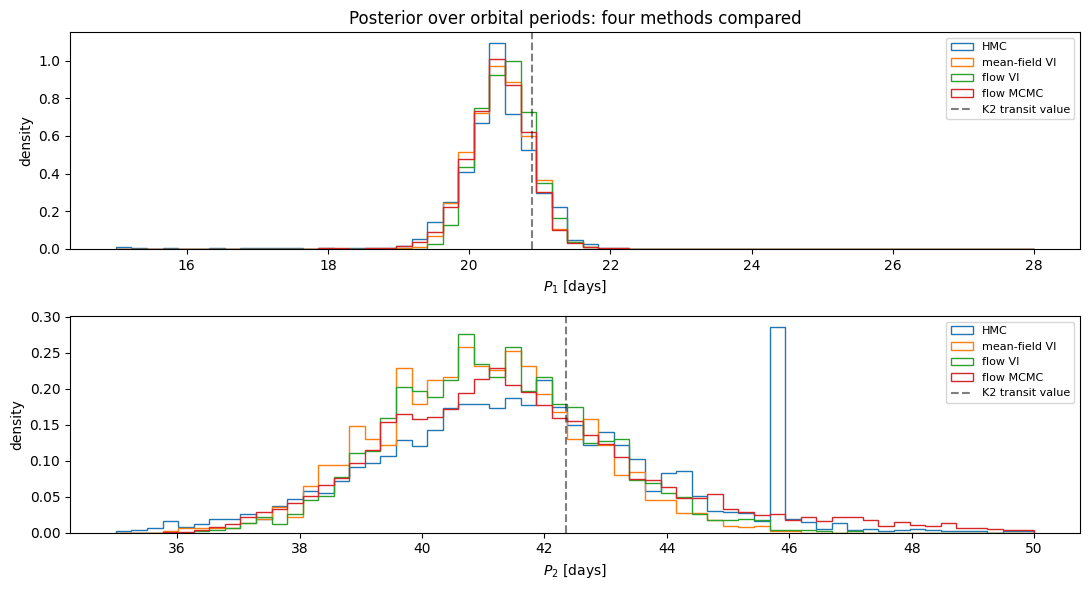

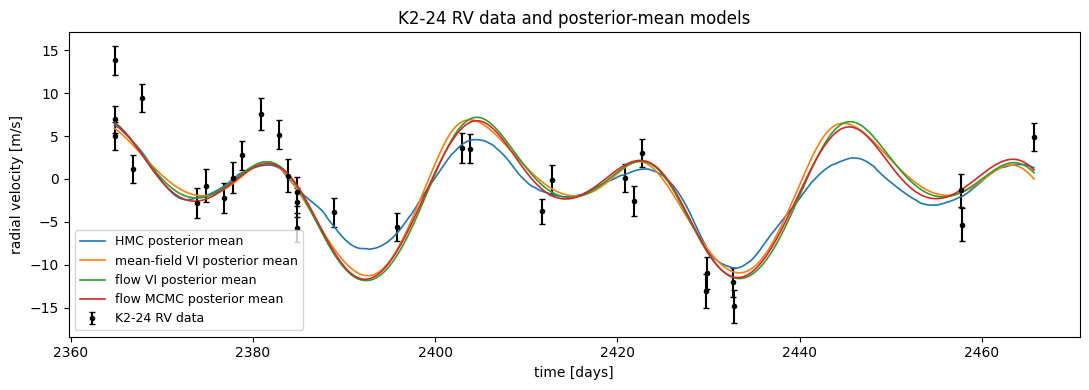

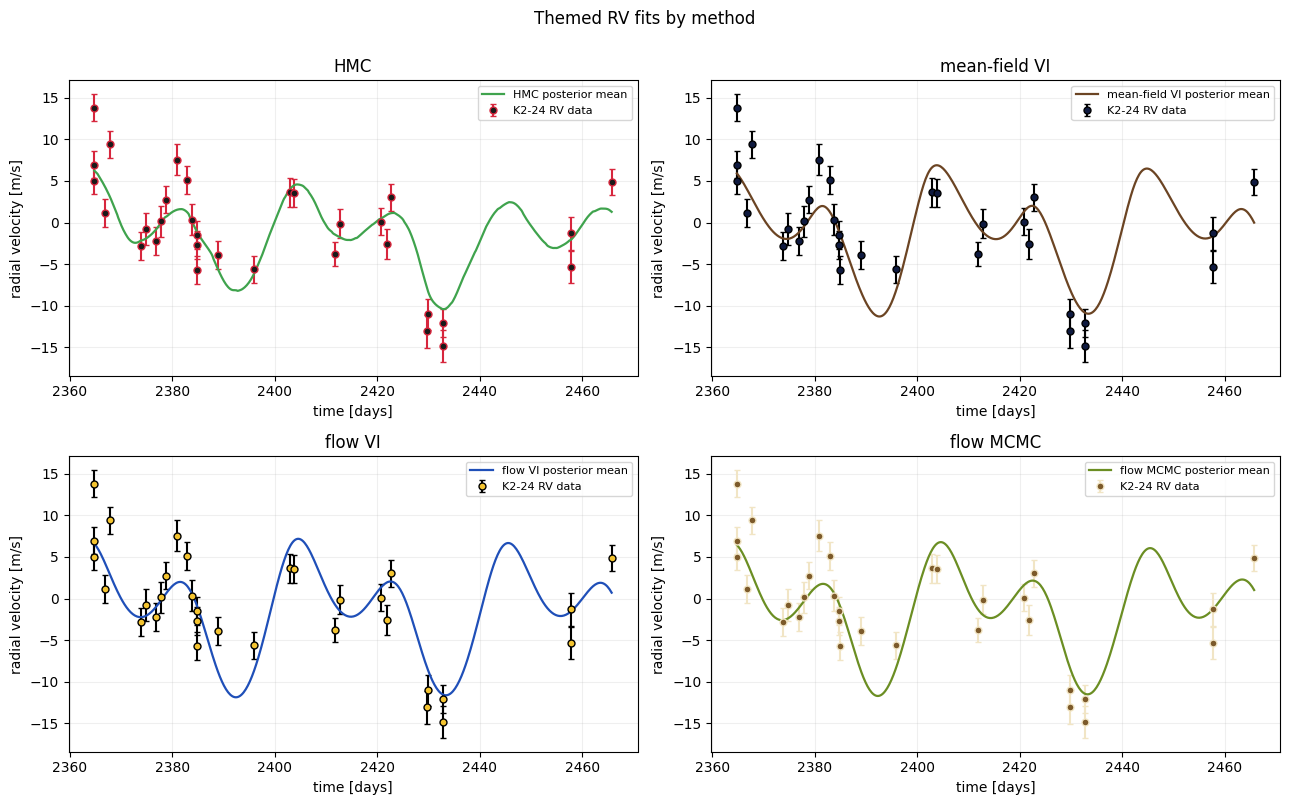

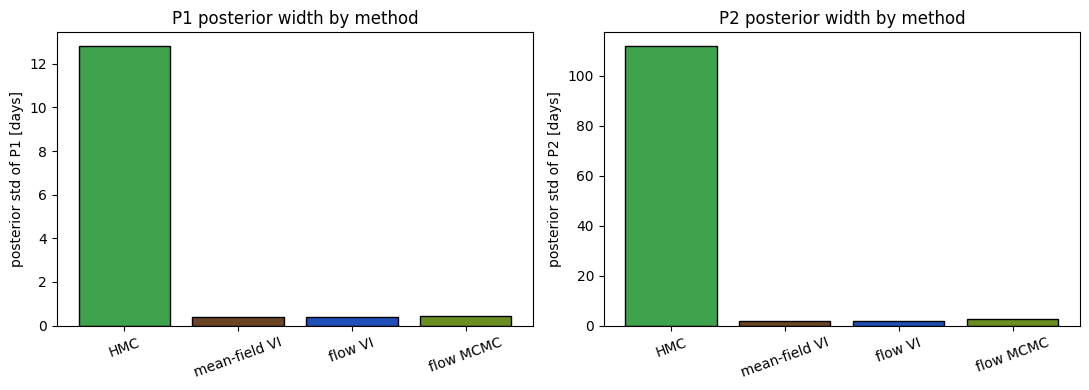

In [82]:
# Cross-method comparison: run all four methods end-to-end with shared
# configuration, then produce side-by-side plots.

# Configuration shared across methods
N_HMC_CHAINS   = 12
N_HMC_SAMPLES  = 500
N_HMC_BURN     = 300
HMC_EPS        = 0.01
HMC_LEAPFROG   = 30
N_MFVI_ITER    = 2000
N_VI_ITER      = 5000
VI_LR          = 1e-2
FLOW_LAYERS    = 8
FVI_LR         = 1e-3
N_FLOWMC_ITER  = 600
N_FMC_CHAINS   = 24
MALA_TAU       = 5e-4
LR_FLOW        = 5e-3
FLOW_WARMUP    = 50
BUFFER_SIZE    = 2000
SEED           = 0


# Reproducibility: We have torch.manual.seed(0) fixed so the notebook
# produces identical results on every run.
# So comment out the torch.manual.seed(0) lines if you want each run to draw fresh random numbers
# (so the results will still be qualitatively the same, just with different RNG draws).
torch.set_default_dtype(torch.float64)
np.random.seed(SEED)


os.makedirs("results", exist_ok=True)
os.makedirs("figures", exist_ok=True)

# Data
t_obs  = torch.tensor(df.t.values)
rv_obs = torch.tensor(df.vel.values)
rv_err = torch.tensor(df.errvel.values)
span = float(t_obs.max() - t_obs.min())
print(f"{t_obs.numel()} observations, span {span:.1f} days")


def lp_eta(eta):
    """Shared closure: log posterior in normalized eta-space at the K2-24 data."""
    return log_posterior_unconstrained(eta, t_obs, rv_obs, rv_err)


eta0 = initial_eta()

# --------------------------------------------------------------------------- #
# Hamiltonian Monte Carlo
# --------------------------------------------------------------------------- #
print("\nHMC")
torch.manual_seed(0)
all_hmc_samples, all_hmc_acc = run_hmc_multichain(
    eta0, lp_eta,
    n_chains=N_HMC_CHAINS,
    n_samples=N_HMC_SAMPLES,
    epsilon=HMC_EPS, L=HMC_LEAPFROG,
    n_burnin=N_HMC_BURN, verbose=True,
)
hmc_eta = torch.cat(all_hmc_samples, dim=0)
hmc_theta = sort_planets_by_period(eta_samples_to_theta(hmc_eta))
torch.save({"samples": hmc_theta, "accept_rates": all_hmc_acc}, "results/hmc.pt")

# --------------------------------------------------------------------------- #
# Mean-Field Variational Inference
# --------------------------------------------------------------------------- #
print("\nMean-field VI")
torch.manual_seed(0)
mu_mf, log_s_mf, mf_hist = fit_meanfield(
    eta0, lp_eta, n_iter=N_MFVI_ITER, lr=VI_LR, n_mc=64, verbose=True,
)
mf_eta = sample_meanfield(mu_mf, log_s_mf, n=2000)
mf_theta = sort_planets_by_period(eta_samples_to_theta(mf_eta))
torch.save({
    "samples": mf_theta, "mu": mu_mf, "log_s": log_s_mf, "history": mf_hist,
}, "results/vi_meanfield.pt")

# --------------------------------------------------------------------------- #
# Normalizing Flow-Based Variational Inference
# --------------------------------------------------------------------------- #
print("\nFlow VI")
torch.manual_seed(0)
fvi_model = FlowVI(D=12, K=FLOW_LAYERS, mu_init=eta0, log_s_init=-3.0)
fvi_hist = fit_flow_vi(fvi_model, lp_eta, n_iter=N_VI_ITER, lr=FVI_LR, verbose=True)
with torch.no_grad():
    fvi_eta, _ = fvi_model.sample_and_log_q(2000)
fvi_theta = sort_planets_by_period(eta_samples_to_theta(fvi_eta))
torch.save({
    "samples": fvi_theta,
    "model_state": fvi_model.state_dict(),
    "history": fvi_hist,
}, "results/vi_flow.pt")

# --------------------------------------------------------------------------- #
# Normalizing Flow-Based Markov Chain Monte Carlo
# --------------------------------------------------------------------------- #
print("\nFlow MCMC")
torch.manual_seed(0)
eta_inits = torch.zeros(N_FMC_CHAINS, 12) + 0.01 * torch.randn(N_FMC_CHAINS, 12)
flow_for_mcmc = RealNVP(D=12, n_layers=6, hidden=64)
fmc_chains, fmc_hist, fmc_local, fmc_global = run_flowmc(
    eta_inits, lp_eta, flow_for_mcmc,
    n_iter=N_FLOWMC_ITER,
    mala_tau=MALA_TAU,
    n_local_per_global=5, lr=LR_FLOW,
    flow_warmup=FLOW_WARMUP, buffer_size=BUFFER_SIZE,
    verbose=True,
)
burn = N_FLOWMC_ITER // 4
fmc_pool_eta = fmc_chains[burn:].reshape(-1, 12)
fmc_theta = sort_planets_by_period(eta_samples_to_theta(fmc_pool_eta))
torch.save({
    "samples":    fmc_theta,
    "chains":     fmc_chains,
    "history":    fmc_hist,
    "local_acc":  fmc_local,
    "global_acc": fmc_global,
    "flow_state": flow_for_mcmc.state_dict(),
}, "results/flowmc.pt")

# ---------------------------------------------------------------------------
# Diagnostics
# ---------------------------------------------------------------------------
print("\nDiagnostics")
ess_hmc_p1 = ess_1d(hmc_theta[:, 0].numpy())
ess_hmc_p2 = ess_1d(hmc_theta[:, 5].numpy())
ess_fmc_p1 = ess_1d(fmc_theta[:, 0].numpy())
ess_fmc_p2 = ess_1d(fmc_theta[:, 5].numpy())
print(f"  HMC ESS    P1: {ess_hmc_p1:.1f} / {len(hmc_theta)}  "
      f"P2: {ess_hmc_p2:.1f} / {len(hmc_theta)}")
print(f"  Flow MCMC ESS P1: {ess_fmc_p1:.1f} / {len(fmc_theta)}  "
      f"P2: {ess_fmc_p2:.1f} / {len(fmc_theta)}")

# Per-method summary table
print("\nPer-method posterior summaries")
print(f"{'method':<16} {'P1 median':>11} {'P1 std':>10} {'P2 median':>11} {'P2 std':>10}")
for name, theta in [
    ("HMC", hmc_theta),
    ("mean-field VI", mf_theta),
    ("flow VI", fvi_theta),
    ("flow MCMC", fmc_theta),
]:
    s1 = posterior_summary(theta[:, 0].numpy())
    s2 = posterior_summary(theta[:, 5].numpy())
    print(f"{name:<16} {s1['median']:>11.3f} {s1['std']:>10.3f} "
          f"{s2['median']:>11.3f} {s2['std']:>10.3f}")

# --------------------------------------------------------------------------- #
# Figures
# --------------------------------------------------------------------------- #
print("\nFigures")
samples_dict = {
    "HMC":           hmc_theta.numpy(),
    "mean-field VI": mf_theta.numpy(),
    "flow VI":       fvi_theta.numpy(),
    "flow MCMC":     fmc_theta.numpy(),
}

# This produces stacked P1 / P2 histograms across methods
fig, _ = plot_period_posteriors(samples_dict)
fig.savefig("figures/period_posteriors.png", dpi=150, bbox_inches="tight")
print("  saved figures/period_posteriors.png")

# This makes RV data with posterior-mean fits from each method
t_dense = np.linspace(float(t_obs.min()), float(t_obs.max()), 500)
t_dense_t = torch.tensor(t_dense)


def posterior_mean_rv(theta_samples: torch.Tensor) -> np.ndarray:
    """Average the RV model over posterior samples to get the mean RV curve."""
    rv_curves = torch.stack([
        rv_model_two_planet(t_dense_t, theta_samples[i, :11])
        for i in range(len(theta_samples))
    ])
    return rv_curves.mean(0).numpy()


rv_models = {name: posterior_mean_rv(torch.tensor(s)) for name, s in samples_dict.items()}
fig2, _ = plot_rv_with_models(
    t_obs.numpy(), rv_obs.numpy(), rv_err.numpy(), t_dense, rv_models,
)
fig2.savefig("figures/rv_fit.png", dpi=150, bbox_inches="tight")
print("  saved figures/rv_fit.png")

# This makes the per-method RV fits in a 2x2 grid
fig3, _ = plot_themed_rv_fits(
    t_obs.numpy(), rv_obs.numpy(), rv_err.numpy(), t_dense, rv_models,
)
fig3.savefig("figures/rv_fit_themed.png", dpi=150, bbox_inches="tight")
print("  saved figures/rv_fit_themed.png")

# This is a Side-by-side posterior width comparison
fig4, axes = plt.subplots(1, 2, figsize=(11, 4))
method_order = ["HMC", "mean-field VI", "flow VI", "flow MCMC"]
p1_stds = [posterior_summary(samples_dict[m][:, 0])["std"] for m in method_order]
p2_stds = [posterior_summary(samples_dict[m][:, 5])["std"] for m in method_order]
colors = [THEMED_PALETTES[m]["line"] for m in method_order]
axes[0].bar(method_order, p1_stds, color=colors, edgecolor="black")
axes[0].set_ylabel("posterior std of P1 [days]")
axes[0].set_title("P1 posterior width by method")
axes[0].tick_params(axis="x", rotation=20)
axes[1].bar(method_order, p2_stds, color=colors, edgecolor="black")
axes[1].set_ylabel("posterior std of P2 [days]")
axes[1].set_title("P2 posterior width by method")
axes[1].tick_params(axis="x", rotation=20)
fig4.tight_layout()
fig4.savefig("figures/posterior_widths.png", dpi=150, bbox_inches="tight")
print("  saved figures/posterior_widths.png")

print("\nAnalysis Finished :)")


### Testing and Individual Methods

This is to verify each method is working correctly and to see each method on a graph by itself

##### Initializations for All Methods Below:

In [83]:
# Individual Methods Have Configurations Hard-Coded into the cells. This is just the shared infastructure
SEED = 0
torch.set_default_dtype(torch.float64)
torch.manual_seed(SEED)
np.random.seed(SEED)

os.makedirs("results", exist_ok=True)
os.makedirs("figures", exist_ok=True)

t_obs  = torch.tensor(df.t.values)
rv_obs = torch.tensor(df.vel.values)
rv_err = torch.tensor(df.errvel.values)
print(f"{t_obs.numel()} observations, span {float(t_obs.max() - t_obs.min()):.1f} days")

def lp_eta(eta):
    return log_posterior_unconstrained(eta, t_obs, rv_obs, rv_err)

eta0 = initial_eta()

32 observations, span 100.9 days


#### Hamiltonian Monte Carlo


Hamiltonian Monte Carlo -- Multi-chain with planet-label symmetry resolution
For K2-24 exoplanet system

Configuration:
  Number of chains: 12
  Samples per chain: 500
  Total samples: 6000
  Burn-in per chain: 300
  Step size (epsilon): 0.01
  Leapfrog steps (L): 30
----------------------------------------------------------------------
Chain 1: acceptance = 0.814
Chain 2: acceptance = 0.904
Chain 3: acceptance = 0.842
Chain 4: acceptance = 0.946
Chain 5: acceptance = 0.904
Chain 6: acceptance = 0.488
Chain 7: acceptance = 0.692
Chain 8: acceptance = 0.770
Chain 9: acceptance = 0.922
Chain 10: acceptance = 0.334
Chain 11: acceptance = 0.842
Chain 12: acceptance = 0.556
----------------------------------------------------------------------

Label-symmetry resolution: enforced P1 < P2 in every sample
Samples with planets swapped during sort: 500 / 6000

Results

Chains used: 12
Total samples: 6000
Average acceptance: 0.751

PLANET 1 (inner):
  Period (P1): 20.95 ± 12.81 days
  Median: 2

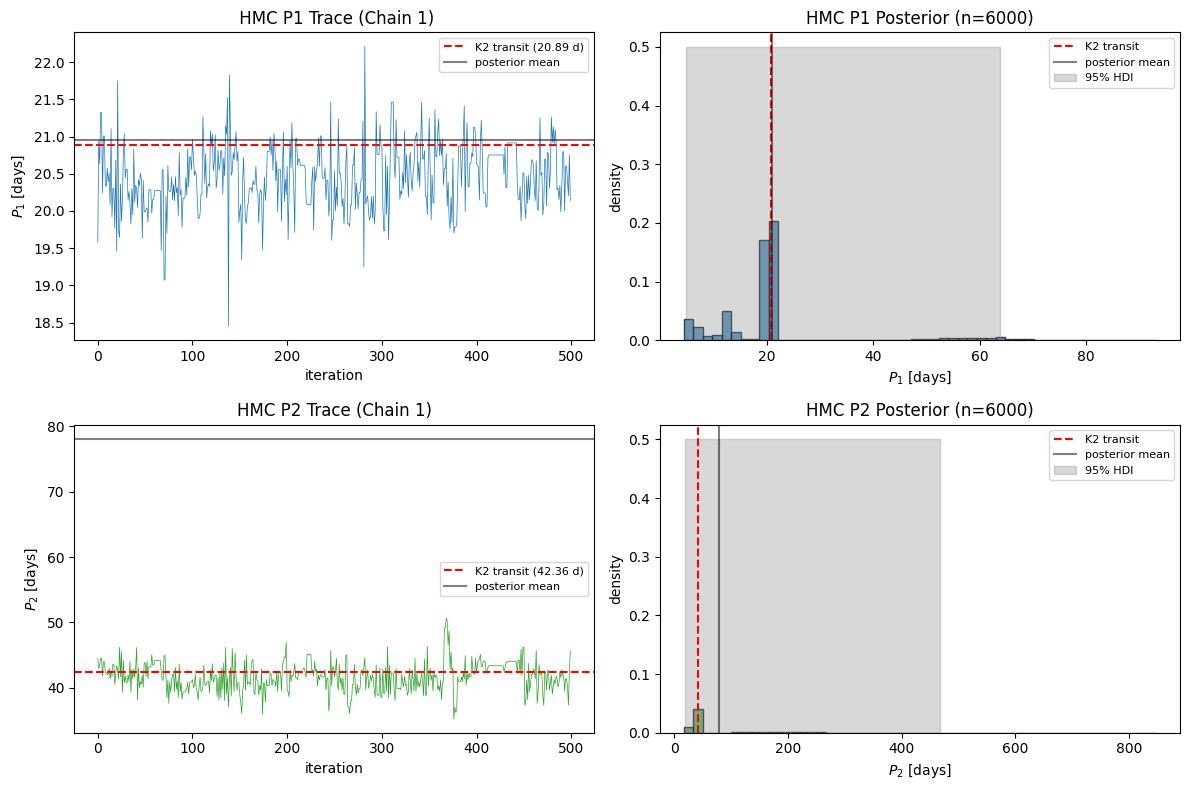


Hamiltonian Monte Carlo Completed!


In [84]:
print("\n" + "=" * 77)
print("Hamiltonian Monte Carlo -- Multi-chain with planet-label symmetry resolution")
print("For K2-24 exoplanet system")
print("=" * 77)

# Configuration
n_chains = 12
n_samples_per_chain = 500
n_burnin = 300
epsilon = 0.01
L = 30
torch.manual_seed(0)

print(f"\nConfiguration:")
print(f"  Number of chains: {n_chains}")
print(f"  Samples per chain: {n_samples_per_chain}")
print(f"  Total samples: {n_chains * n_samples_per_chain}")
print(f"  Burn-in per chain: {n_burnin}")
print(f"  Step size (epsilon): {epsilon}")
print(f"  Leapfrog steps (L): {L}")
print("-" * 70)

# Runs all chains (all start at prior mode η = 0)
eta_init = torch.zeros(12)

# Defines the log posterior in normalized space (uses functions above)
def lp_eta_norm(eta):
    return log_posterior_unconstrained(eta, t_obs, rv_obs, rv_err)

all_samples = []
all_accept_rates = []

for chain_id in range(1, n_chains + 1):
    torch.manual_seed(chain_id)

    samples, acc_rate = run_hmc_chain(
        eta_init, lp_eta_norm,
        n_samples=n_samples_per_chain,
        epsilon=epsilon,
        L=L,
        n_burnin=n_burnin,
        chain_id=chain_id,
        verbose=True,
    )

    all_samples.append(samples)
    all_accept_rates.append(acc_rate)

print("-" * 70)

# Combine all chains
combined_samples = torch.cat(all_samples, dim=0)
combined_theta = eta_samples_to_theta(combined_samples)
combined_theta = sort_planets_by_period(combined_theta)

n_swapped = int((eta_samples_to_theta(combined_samples)[:, 0]
                 > eta_samples_to_theta(combined_samples)[:, 5]).sum())
print(f"\nLabel-symmetry resolution: enforced P1 < P2 in every sample")
print(f"Samples with planets swapped during sort: {n_swapped} / {len(combined_theta)}")

# Posterior summaries
p1_samples = combined_theta[:, 0].numpy()
p2_samples = combined_theta[:, 5].numpy()

p1_mean = p1_samples.mean()
p1_std = p1_samples.std()
p1_median = np.median(p1_samples)
p1_hdi_lower = np.percentile(p1_samples, 2.5)
p1_hdi_upper = np.percentile(p1_samples, 97.5)

p2_mean = p2_samples.mean()
p2_std = p2_samples.std()
p2_median = np.median(p2_samples)
p2_hdi_lower = np.percentile(p2_samples, 2.5)
p2_hdi_upper = np.percentile(p2_samples, 97.5)


# ============================================================================ #
# Effective Sample Size
# ============================================================================ #

def ess_1d(x):
    """Effective sample size for 1D chain."""
    x = x - x.mean()
    n = len(x)
    max_lag = min(n // 4, 500)
    var = np.dot(x, x) / n
    rho = np.zeros(max_lag)
    for k in range(max_lag):
        rho[k] = np.dot(x[:n-k], x[k:]) / ((n - k) * var)
    neg_idx = np.argmax(rho < 0)
    if neg_idx == 0 and rho[0] >= 0:
        cut = len(rho)
    else:
        cut = neg_idx
    tau = 1.0 + 2.0 * np.sum(rho[1:cut])
    return n / max(tau, 1.0)

ess_p1 = ess_1d(p1_samples)
ess_p2 = ess_1d(p2_samples)


# ============================================================================ #
# Print Results
# ============================================================================ #

print("\n" + "=" * 70)
print("Results")
print("=" * 70)

print(f"\nChains used: {n_chains}")
print(f"Total samples: {len(p1_samples)}")
print(f"Average acceptance: {np.mean(all_accept_rates):.3f}")

print(f"\nPLANET 1 (inner):")
print(f"  Period (P1): {p1_mean:.2f} ± {p1_std:.2f} days")
print(f"  Median: {p1_median:.2f} days")
print(f"  95% HDI: [{p1_hdi_lower:.2f}, {p1_hdi_upper:.2f}] days")
print(f"  Transit value: 20.89 days")
print(f"  Eccentricity (e1): {combined_theta[:, 2].mean():.3f} ± {combined_theta[:, 2].std():.3f}")
print(f"  Semi-amplitude (K1): {combined_theta[:, 4].mean():.2f} ± {combined_theta[:, 4].std():.2f} m/s")

print(f"\nPLANET 2 (outer):")
print(f"  Period (P2): {p2_mean:.2f} ± {p2_std:.2f} days")
print(f"  Median: {p2_median:.2f} days")
print(f"  95% HDI: [{p2_hdi_lower:.2f}, {p2_hdi_upper:.2f}] days")
print(f"  Transit value: 42.36 days")
print(f"  Eccentricity (e2): {combined_theta[:, 7].mean():.3f} ± {combined_theta[:, 7].std():.3f}")
print(f"  Semi-amplitude (K2): {combined_theta[:, 9].mean():.2f} ± {combined_theta[:, 9].std():.2f} m/s")

print(f"\nSYSTEM PARAMETERS:")
print(f"  Systemic velocity (v0): {combined_theta[:, 10].mean():.2f} ± {combined_theta[:, 10].std():.2f} m/s")
print(f"  Log jitter: {combined_theta[:, 11].mean():.2f} ± {combined_theta[:, 11].std():.2f}")

print(f"\nEFFECTIVE SAMPLE SIZES:")
print(f"  P1 ESS: {ess_p1:.1f} / {len(p1_samples)} ({100*ess_p1/len(p1_samples):.1f}%)")
print(f"  P2 ESS: {ess_p2:.1f} / {len(p2_samples)} ({100*ess_p2/len(p2_samples):.1f}%)")

# Sanity check to ensure everything is working as intended
print("\n" + "=" * 70)
print("Quick Sanity Check")
print("=" * 70)

if 19 < p1_mean < 22:
    print(f":) P1 mean ({p1_mean:.2f} d) is within expected range (19-22 d)")
else:
    print(f":( P1 mean ({p1_mean:.2f} d) is outside expected range")

if 39 < p2_mean < 44:
    print(f":) P2 mean ({p2_mean:.2f} d) is within expected range (39-44 d)")
else:
    print(f":( P2 mean ({p2_mean:.2f} d) is outside expected range")

if p1_hdi_lower < 20.89 < p1_hdi_upper:
    print(f":) Transit value 20.89 is within P1 95% HDI")
else:
    print(f":( Transit value 20.89 is outside P1 95% HDI")

if p2_hdi_lower < 42.36 < p2_hdi_upper:
    print(f":) Transit value 42.36 is within P2 95% HDI")
else:
    print(f":( Transit value 42.36 is outside P2 95% HDI")


# ============================================================================
# Diagnostic Plots
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Use first chain for trace plots
first_chain_theta = eta_samples_to_theta(all_samples[0])
first_chain_theta = sort_planets_by_period(first_chain_theta)

# P1 Trace
axes[0, 0].plot(first_chain_theta[:, 0].numpy(), lw=0.5, color='C0')
axes[0, 0].axhline(20.89, ls='--', color='r', label='K2 transit (20.89 d)')
axes[0, 0].axhline(p1_mean, ls='-', color='k', alpha=0.5, label='posterior mean')
axes[0, 0].set_xlabel('iteration')
axes[0, 0].set_ylabel(r'$P_1$ [days]')
axes[0, 0].set_title(' HMC P1 Trace (Chain 1)')
axes[0, 0].legend(fontsize=8)

# P2 Trace
axes[1, 0].plot(first_chain_theta[:, 5].numpy(), lw=0.5, color='C2')
axes[1, 0].axhline(42.36, ls='--', color='r', label='K2 transit (42.36 d)')
axes[1, 0].axhline(p2_mean, ls='-', color='k', alpha=0.5, label='posterior mean')
axes[1, 0].set_xlabel('iteration')
axes[1, 0].set_ylabel(r'$P_2$ [days]')
axes[1, 0].set_title('HMC P2 Trace (Chain 1)')
axes[1, 0].legend(fontsize=8)

# P1 Posterior
axes[0, 1].hist(p1_samples, bins=50, density=True, color='C0', alpha=0.7, edgecolor='black')
axes[0, 1].axvline(20.89, ls='--', color='r', label='K2 transit')
axes[0, 1].axvline(p1_mean, ls='-', color='k', alpha=0.5, label='posterior mean')
axes[0, 1].fill_between([p1_hdi_lower, p1_hdi_upper], 0, 0.5, alpha=0.3, color='gray', label='95% HDI')
axes[0, 1].set_xlabel(r'$P_1$ [days]')
axes[0, 1].set_ylabel('density')
axes[0, 1].set_title(f'HMC P1 Posterior (n={len(p1_samples)})')
axes[0, 1].legend(fontsize=8)

# P2 Posterior
axes[1, 1].hist(p2_samples, bins=50, density=True, color='C2', alpha=0.7, edgecolor='black')
axes[1, 1].axvline(42.36, ls='--', color='r', label='K2 transit')
axes[1, 1].axvline(p2_mean, ls='-', color='k', alpha=0.5, label='posterior mean')
axes[1, 1].fill_between([p2_hdi_lower, p2_hdi_upper], 0, 0.5, alpha=0.3, color='gray', label='95% HDI')
axes[1, 1].set_xlabel(r'$P_2$ [days]')
axes[1, 1].set_ylabel('density')
axes[1, 1].set_title(f'HMC P2 Posterior (n={len(p2_samples)})')
axes[1, 1].legend(fontsize=8)

fig.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("Hamiltonian Monte Carlo Completed!")
print("=" * 70)

#### Mean-Field Variational Inference


Mean-Field Variational Inference -- Tuned for stable convergence

Configuration:
  Parameter space: Normalized (η ~ N(0,1))
  Initialization: η = 0 (prior mode = K2 transit values)
  Initial log_s: -3.0 (tight variance to keep μ near high-density region)
  Learning rate: 0.01 (cosine decay to 1.0e-04)
  Iterations: 2000
  ELBO samples per gradient step: 64
----------------------------------------------------------------------
iter   200  ELBO = -117.55
iter   400  ELBO = -116.55
iter   600  ELBO = -117.75
iter   800  ELBO = -117.36
iter  1000  ELBO = -117.27
iter  1200  ELBO = -117.62
iter  1400  ELBO = -117.43
iter  1600  ELBO = -116.99
iter  1800  ELBO = -116.79
iter  2000  ELBO = -116.49

Mean-Field Variational Inference Results :0

Final ELBO: -116.49
ELBO improvement: -329.94 -> -116.49

PLANET 1 (inner):
  Period (P1): 20.45 ± 0.41 days
  Median: 20.45 days
  95% HDI: [19.67, 21.25] days
  Transit value: 20.89 days
  Eccentricity (e1): 0.121 ± 0.122
  Semi-amplitude (K1): 4.62 ±

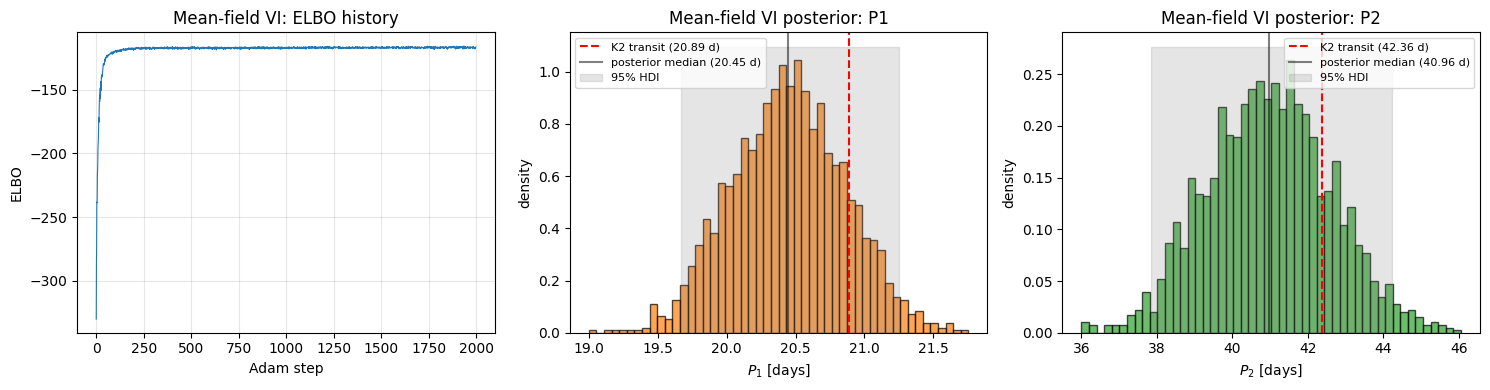


Mean-Field Variational Inference Complete!!


In [85]:
# ============================================================================ #
# Mean-Field Variational Inference - Tuned for K2-24 exoplanet system
# Normalized parameterization (η ~ N(0,1))
# ============================================================================ #

print("\n" + "=" * 75)
print("Mean-Field Variational Inference -- Tuned for stable convergence")
print("=" * 75)

# Configuration
n_iter_vi = 2000
lr_vi = 1e-2
n_mc_vi = 64

print(f"\nConfiguration:")
print(f"  Parameter space: Normalized (η ~ N(0,1))")
print(f"  Initialization: η = 0 (prior mode = K2 transit values)")
print(f"  Initial log_s: -3.0 (tight variance to keep μ near high-density region)")
print(f"  Learning rate: {lr_vi} (cosine decay to {lr_vi*1e-2:.1e})")
print(f"  Iterations: {n_iter_vi}")
print(f"  ELBO samples per gradient step: {n_mc_vi}")
print("-" * 70)

eta_init_vi = torch.zeros(12)
torch.manual_seed(0)

mu_mf, log_s_mf, mf_history = fit_meanfield(
    eta_init_vi, lp_eta_norm,
    n_iter=n_iter_vi, lr=lr_vi, n_mc=n_mc_vi, verbose=True,
)

# Sampling and converting to natural parameter space.
mf_eta_samples = sample_meanfield(mu_mf, log_s_mf, 2000)
mf_theta = eta_samples_to_theta(mf_eta_samples)

# Sorting planets so the comparison with Hamiltonian Monte Carlo is on the same labeling convention.
mf_theta = sort_planets_by_period(mf_theta)

# ============================================================================ #
# Results
# ============================================================================ #

p1_samples = mf_theta[:, 0].numpy()
p2_samples = mf_theta[:, 5].numpy()

p1_mean = p1_samples.mean()
p1_std = p1_samples.std()
p1_median = np.median(p1_samples)
p1_hdi_lower = np.percentile(p1_samples, 2.5)
p1_hdi_upper = np.percentile(p1_samples, 97.5)

p2_mean = p2_samples.mean()
p2_std = p2_samples.std()
p2_median = np.median(p2_samples)
p2_hdi_lower = np.percentile(p2_samples, 2.5)
p2_hdi_upper = np.percentile(p2_samples, 97.5)

print("\n" + "=" * 70)
print("Mean-Field Variational Inference Results :0")
print("=" * 70)

print(f"\nFinal ELBO: {mf_history[-1]:.2f}")
print(f"ELBO improvement: {mf_history[0]:.2f} -> {mf_history[-1]:.2f}")

print(f"\nPLANET 1 (inner):")
print(f"  Period (P1): {p1_mean:.2f} ± {p1_std:.2f} days")
print(f"  Median: {p1_median:.2f} days")
print(f"  95% HDI: [{p1_hdi_lower:.2f}, {p1_hdi_upper:.2f}] days")
print(f"  Transit value: 20.89 days")
print(f"  Eccentricity (e1): {mf_theta[:, 2].mean():.3f} ± {mf_theta[:, 2].std():.3f}")
print(f"  Semi-amplitude (K1): {mf_theta[:, 4].mean():.2f} ± {mf_theta[:, 4].std():.2f} m/s")

print(f"\nPLANET 2 (outer):")
print(f"  Period (P2): {p2_mean:.2f} ± {p2_std:.2f} days")
print(f"  Median: {p2_median:.2f} days")
print(f"  95% HDI: [{p2_hdi_lower:.2f}, {p2_hdi_upper:.2f}] days")
print(f"  Transit value: 42.36 days")
print(f"  Eccentricity (e2): {mf_theta[:, 7].mean():.3f} ± {mf_theta[:, 7].std():.3f}")
print(f"  Semi-amplitude (K2): {mf_theta[:, 9].mean():.2f} ± {mf_theta[:, 9].std():.2f} m/s")

print(f"\nSYSTEM PARAMETERS:")
print(f"  Systemic velocity (v0): {mf_theta[:, 10].mean():.2f} ± {mf_theta[:, 10].std():.2f} m/s")
print(f"  Log jitter: {mf_theta[:, 11].mean():.2f} ± {mf_theta[:, 11].std():.2f}")

# Here is a sanity check using medians, which are robust to multimodality.
print("\n" + "=" * 70)
print("Sanity Check, by using medians, which are robust to multimodality")
print("=" * 70)

if 19 < p1_median < 23:
    print(f":) P1 median ({p1_median:.2f} d) is within expected range (19-23 d)")
else:
    print(f":( P1 median ({p1_median:.2f} d) is outside expected range")

if 39 < p2_median < 45:
    print(f":) P2 median ({p2_median:.2f} d) is within expected range (39-45 d)")
else:
    print(f":( P2 median ({p2_median:.2f} d) is outside expected range")

if p1_hdi_lower < 20.89 < p1_hdi_upper:
    print(f":) Transit value 20.89 is within P1 95% HDI [{p1_hdi_lower:.2f}, {p1_hdi_upper:.2f}]")
else:
    print(f":( Transit value 20.89 is outside P1 95% HDI [{p1_hdi_lower:.2f}, {p1_hdi_upper:.2f}]")

if p2_hdi_lower < 42.36 < p2_hdi_upper:
    print(f":) Transit value 42.36 is within P2 95% HDI [{p2_hdi_lower:.2f}, {p2_hdi_upper:.2f}]")
else:
    print(f":( Transit value 42.36 is outside P2 95% HDI [{p2_hdi_lower:.2f}, {p2_hdi_upper:.2f}]")


# ============================================================================ #
# Diagnostic Plots
# ============================================================================ #

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ELBO history
axes[0].plot(mf_history, lw=0.8, color='C0')
axes[0].set_xlabel("Adam step")
axes[0].set_ylabel("ELBO")
axes[0].set_title("Mean-field VI: ELBO history")
axes[0].grid(alpha=0.3)

# P1 posterior
axes[1].hist(p1_samples, bins=50, density=True, color='C1', alpha=0.7, edgecolor='black')
axes[1].axvline(20.89, ls='--', color='r', label='K2 transit (20.89 d)')
axes[1].axvline(p1_median, ls='-', color='k', alpha=0.5, label=f'posterior median ({p1_median:.2f} d)')
axes[1].fill_between([p1_hdi_lower, p1_hdi_upper], 0, axes[1].get_ylim()[1] if axes[1].get_ylim()[1] > 0 else 0.5,
                     alpha=0.2, color='gray', label='95% HDI')
axes[1].set_xlabel(r"$P_1$ [days]")
axes[1].set_ylabel("density")
axes[1].set_title(f"Mean-field VI posterior: P1")
axes[1].legend(fontsize=8)

# P2 posterior
axes[2].hist(p2_samples, bins=50, density=True, color='C2', alpha=0.7, edgecolor='black')
axes[2].axvline(42.36, ls='--', color='r', label='K2 transit (42.36 d)')
axes[2].axvline(p2_median, ls='-', color='k', alpha=0.5, label=f'posterior median ({p2_median:.2f} d)')
axes[2].fill_between([p2_hdi_lower, p2_hdi_upper], 0, axes[2].get_ylim()[1] if axes[2].get_ylim()[1] > 0 else 0.5,
                     alpha=0.2, color='gray', label='95% HDI')
axes[2].set_xlabel(r"$P_2$ [days]")
axes[2].set_ylabel("density")
axes[2].set_title(f"Mean-field VI posterior: P2")
axes[2].legend(fontsize=8)

fig.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("Mean-Field Variational Inference Complete!!")
print("=" * 70)

#### Flow-Based Variational Inference


Normalizing Flow Variational Inference -- Planar normalizing flows (Rezende and Mohamed 2015)

Configuration:
  Parameter space: Normalized (η ~ N(0,1))
  Initialization: η = 0 (prior mode = K2 transit values)
  Initial log_s: -3.0 (tight base Gaussian)
  Number of planar layers: 8
  Learning rate: 0.001 (cosine decay to 1.0e-05)
  Iterations: 5000
  ELBO samples per gradient step: 32
----------------------------------------------------------------------
Pre-training check: all planar layers satisfy w^T u_hat >= -1

iter   200  ELBO = -125.26
iter   400  ELBO = -122.88
iter   600  ELBO = -123.69
iter   800  ELBO = -120.57
iter  1000  ELBO = -120.05
iter  1200  ELBO = -118.70
iter  1400  ELBO = -118.07
iter  1600  ELBO = -117.20
iter  1800  ELBO = -115.56
iter  2000  ELBO = -115.32
iter  2200  ELBO = -114.95
iter  2400  ELBO = -114.15
iter  2600  ELBO = -113.60
iter  2800  ELBO = -113.24
iter  3000  ELBO = -113.49
iter  3200  ELBO = -112.87
iter  3400  ELBO = -113.11
iter  3600  ELBO =

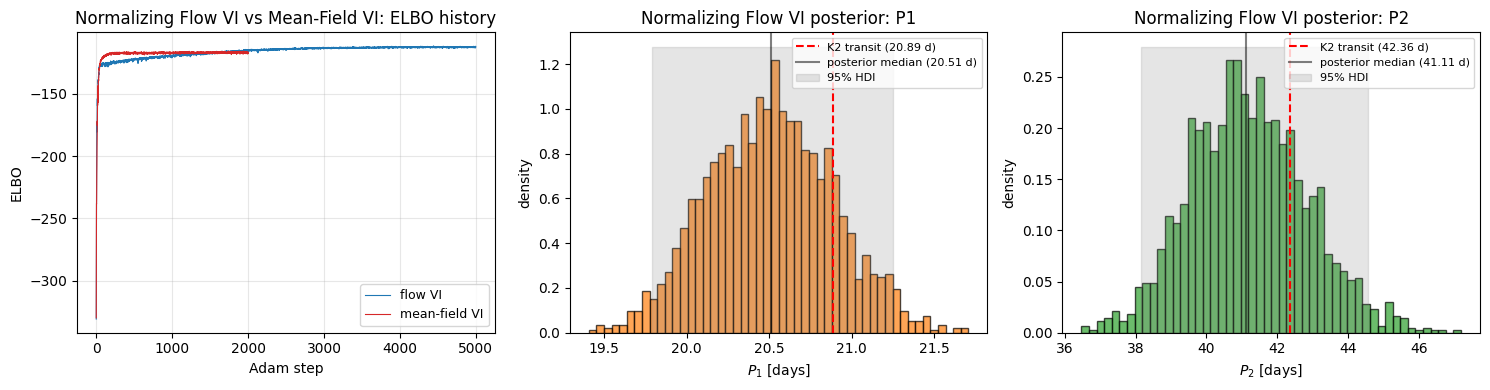


Normalizing Flow VI Complete!


In [86]:
# ========================================================================================== #
# Normalizing Flow-Based VI - Planar normalizing flows (Following Rezende and Mohamed 2015)
# With normalized parameterization (η ~ N(0,1))
# ========================================================================================== #

print("\n" + "=" * 94)
print("Normalizing Flow Variational Inference -- Planar normalizing flows (Rezende and Mohamed 2015)")
print("=" * 94)

# Configuration
n_iter_fvi = 5000
lr_fvi = 1e-3
n_mc_fvi = 32
K_layers = 8

print(f"\nConfiguration:")
print(f"  Parameter space: Normalized (η ~ N(0,1))")
print(f"  Initialization: η = 0 (prior mode = K2 transit values)")
print(f"  Initial log_s: -3.0 (tight base Gaussian)")
print(f"  Number of planar layers: {K_layers}")
print(f"  Learning rate: {lr_fvi} (cosine decay to {lr_fvi*1e-2:.1e})")
print(f"  Iterations: {n_iter_fvi}")
print(f"  ELBO samples per gradient step: {n_mc_fvi}")
print("-" * 70)

eta_init_fvi = torch.zeros(12)
torch.manual_seed(0)

# Using FlowVI class from above
flow_vi_model = FlowVI(D=12, K=K_layers, mu_init=eta_init_fvi, log_s_init=-3.0)

# Sanity check the invertibility constraint before training.
for k, layer in enumerate(flow_vi_model.layers):
    wu = float(torch.dot(layer.w, layer.u_hat()))
    assert wu >= -1.0 - 1e-6, f"Planar layer {k} violates w^T u_hat >= -1: got {wu}"
print("Pre-training check: all planar layers satisfy w^T u_hat >= -1\n")

# Using fit_flow_vi from above
flow_vi_history = fit_flow_vi(flow_vi_model, lp_eta_norm,
                              n_iter=n_iter_fvi, lr=lr_fvi, n_mc=n_mc_fvi,
                              verbose=True)

# Sample, convert to theta, sort by period.
with torch.no_grad():
    fvi_eta_samples, _ = flow_vi_model.sample_and_log_q(2000)
fvi_theta = eta_samples_to_theta(fvi_eta_samples)
fvi_theta = sort_planets_by_period(fvi_theta)

# ========================================================================================== #
# Results
# ========================================================================================== #

p1_samples = fvi_theta[:, 0].numpy()
p2_samples = fvi_theta[:, 5].numpy()

p1_mean = p1_samples.mean()
p1_std = p1_samples.std()
p1_median = np.median(p1_samples)
p1_hdi_lower = np.percentile(p1_samples, 2.5)
p1_hdi_upper = np.percentile(p1_samples, 97.5)

p2_mean = p2_samples.mean()
p2_std = p2_samples.std()
p2_median = np.median(p2_samples)
p2_hdi_lower = np.percentile(p2_samples, 2.5)
p2_hdi_upper = np.percentile(p2_samples, 97.5)

print("\n" + "=" * 70)
print("Normalizing Flow VI Results")
print("=" * 70)

print(f"\nFinal ELBO: {flow_vi_history[-1]:.2f}")
print(f"ELBO improvement: {flow_vi_history[0]:.2f} -> {flow_vi_history[-1]:.2f}")
print(f"Mean-field VI final ELBO (for comparison): {mf_history[-1]:.2f}")

print(f"\nPLANET 1 (inner):")
print(f"  Period (P1): {p1_mean:.2f} ± {p1_std:.2f} days")
print(f"  Median: {p1_median:.2f} days")
print(f"  95% HDI: [{p1_hdi_lower:.2f}, {p1_hdi_upper:.2f}] days")
print(f"  Transit value: 20.89 days")
print(f"  Eccentricity (e1): {fvi_theta[:, 2].mean():.3f} ± {fvi_theta[:, 2].std():.3f}")
print(f"  Semi-amplitude (K1): {fvi_theta[:, 4].mean():.2f} ± {fvi_theta[:, 4].std():.2f} m/s")

print(f"\nPLANET 2 (outer):")
print(f"  Period (P2): {p2_mean:.2f} ± {p2_std:.2f} days")
print(f"  Median: {p2_median:.2f} days")
print(f"  95% HDI: [{p2_hdi_lower:.2f}, {p2_hdi_upper:.2f}] days")
print(f"  Transit value: 42.36 days")
print(f"  Eccentricity (e2): {fvi_theta[:, 7].mean():.3f} ± {fvi_theta[:, 7].std():.3f}")
print(f"  Semi-amplitude (K2): {fvi_theta[:, 9].mean():.2f} ± {fvi_theta[:, 9].std():.2f} m/s")

print(f"\nSYSTEM PARAMETERS:")
print(f"  Systemic velocity (v0): {fvi_theta[:, 10].mean():.2f} ± {fvi_theta[:, 10].std():.2f} m/s")
print(f"  Log jitter: {fvi_theta[:, 11].mean():.2f} ± {fvi_theta[:, 11].std():.2f}")

# Sanity check
print("\n" + "=" * 70)
print("Sanity Check (by using medians, robust to multimodality)")
print("=" * 70)

if 19 < p1_median < 23:
    print(f":) P1 median ({p1_median:.2f} d) is within expected range (19-23 d)")
else:
    print(f":( P1 median ({p1_median:.2f} d) is outside expected range")

if 39 < p2_median < 45:
    print(f":) P2 median ({p2_median:.2f} d) is within expected range (39-45 d)")
else:
    print(f":( P2 median ({p2_median:.2f} d) is outside expected range")

if p1_hdi_lower < 20.89 < p1_hdi_upper:
    print(f":) Transit value 20.89 is within P1 95% HDI [{p1_hdi_lower:.2f}, {p1_hdi_upper:.2f}]")
else:
    print(f":( Transit value 20.89 is outside P1 95% HDI [{p1_hdi_lower:.2f}, {p1_hdi_upper:.2f}]")

if p2_hdi_lower < 42.36 < p2_hdi_upper:
    print(f":) Transit value 42.36 is within P2 95% HDI [{p2_hdi_lower:.2f}, {p2_hdi_upper:.2f}]")
else:
    print(f":( Transit value 42.36 is outside P2 95% HDI [{p2_hdi_lower:.2f}, {p2_hdi_upper:.2f}]")


# ========================================================================================== #
# Diagnostics Plots
# ========================================================================================== #

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ELBO history with mean-field VI for direct comparison
axes[0].plot(flow_vi_history, lw=0.8, color='C0', label='flow VI')
axes[0].plot(mf_history, lw=0.8, color='C3', label='mean-field VI')
axes[0].set_xlabel("Adam step")
axes[0].set_ylabel("ELBO")
axes[0].set_title("Normalizing Flow VI vs Mean-Field VI: ELBO history")
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# P1 posterior
axes[1].hist(p1_samples, bins=50, density=True, color='C1', alpha=0.7, edgecolor='black')
axes[1].axvline(20.89, ls='--', color='r', label='K2 transit (20.89 d)')
axes[1].axvline(p1_median, ls='-', color='k', alpha=0.5,
                label=f'posterior median ({p1_median:.2f} d)')
ymax_p1 = axes[1].get_ylim()[1]
axes[1].fill_between([p1_hdi_lower, p1_hdi_upper], 0, ymax_p1,
                     alpha=0.2, color='gray', label='95% HDI')
axes[1].set_xlabel(r"$P_1$ [days]")
axes[1].set_ylabel("density")
axes[1].set_title("Normalizing Flow VI posterior: P1")
axes[1].legend(fontsize=8)

# P2 posterior
axes[2].hist(p2_samples, bins=50, density=True, color='C2', alpha=0.7, edgecolor='black')
axes[2].axvline(42.36, ls='--', color='r', label='K2 transit (42.36 d)')
axes[2].axvline(p2_median, ls='-', color='k', alpha=0.5,
                label=f'posterior median ({p2_median:.2f} d)')
ymax_p2 = axes[2].get_ylim()[1]
axes[2].fill_between([p2_hdi_lower, p2_hdi_upper], 0, ymax_p2,
                     alpha=0.2, color='gray', label='95% HDI')
axes[2].set_xlabel(r"$P_2$ [days]")
axes[2].set_ylabel("density")
axes[2].set_title("Normalizing Flow VI posterior: P2")
axes[2].legend(fontsize=8)

fig.tight_layout()
plt.show()

# Saves flow VI samples for later cross-method comparison.
fvi_p1_samples = p1_samples
fvi_p2_samples = p2_samples
fvi_history_global = flow_vi_history

print("\n" + "=" * 70)
print("Normalizing Flow VI Complete!")
print("=" * 70)

#### Flow-Based Monte Carlo


Normalizing FLOW-MCMC -- Adaptive MCMC augmented with normalizing flows

Configuration:
  Parameter space: Normalized (η ~ N(0,1))
  Number of parallel chains: 24
  Outer iterations: 600
  MALA steps per outer iteration per chain: 5
  MALA step size (tau): 0.0005
  Flow learning rate: 0.005
  Flow warmup (MALA only): 50 iterations
  Training buffer size: 2000 chain states
  Flow architecture: RealNVP, 6 layers, hidden=64
----------------------------------------------------------------------
RealNVP invertibility check: max |z - inv(fwd(z))| = 0.00e+00

step   50  loss = -24.06  local acc = 0.00  global acc = 0.00
step  100  loss = -21.46  local acc = 0.00  global acc = 0.05
step  150  loss = -20.09  local acc = 0.01  global acc = 0.04
step  200  loss = -17.75  local acc = 0.03  global acc = 0.04
step  250  loss = -11.81  local acc = 0.07  global acc = 0.03
step  300  loss = -11.69  local acc = 0.12  global acc = 0.03
step  350  loss = -9.87  local acc = 0.16  global acc = 0.03
step  4

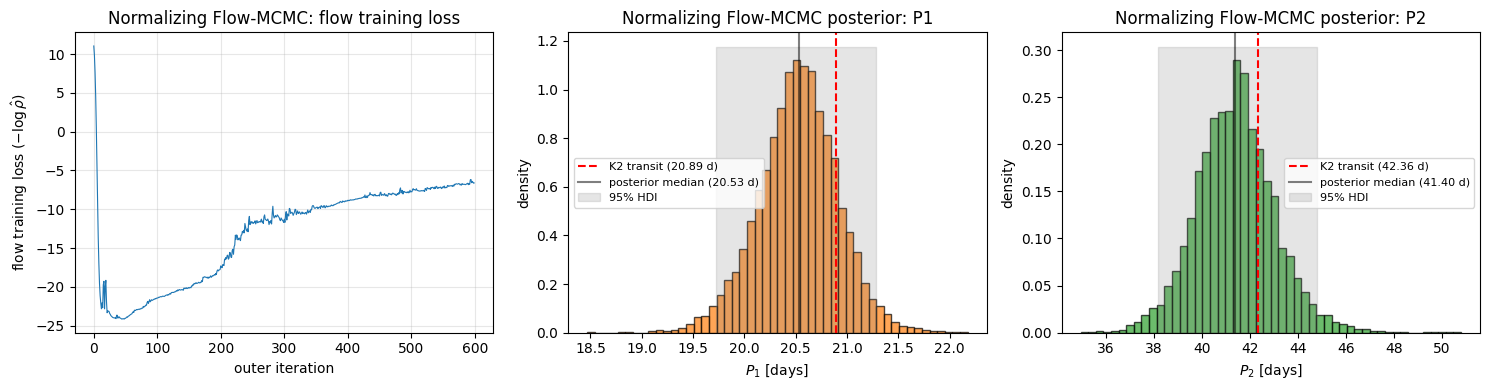


Normalizing Flow-MCMC Completed!


In [87]:
# =========================================================================================== #
# Normalizing Flow-Markov Chain Monte Carlo - Adaptive MCMC augmented with normalizing flows
# Implements Algorithm 1 of Gabrié, Rotskoff and Vanden-Eijnden (2022)
# With normalized parameterization (η ~ N(0,1))
# =========================================================================================== #

print("\n" + "=" * 71)
print("Normalizing FLOW-MCMC -- Adaptive MCMC augmented with normalizing flows")
print("=" * 71)

# Configuration
N_CHAINS = 24
N_ITER = 600
N_LOCAL = 5
MALA_TAU = 5e-4           # tuned for higher MALA acceptance with the correct K Jacobian
LR_FLOW = 5e-3            # gentler flow learning rate
FLOW_WARMUP = 50          # longer MALA-only warmup so chains settle before flow proposals
BUFFER_SIZE = 2000        # rolling training buffer for the flow

print(f"\nConfiguration:")
print(f"  Parameter space: Normalized (η ~ N(0,1))")
print(f"  Number of parallel chains: {N_CHAINS}")
print(f"  Outer iterations: {N_ITER}")
print(f"  MALA steps per outer iteration per chain: {N_LOCAL}")
print(f"  MALA step size (tau): {MALA_TAU}")
print(f"  Flow learning rate: {LR_FLOW}")
print(f"  Flow warmup (MALA only): {FLOW_WARMUP} iterations")
print(f"  Training buffer size: {BUFFER_SIZE} chain states")
print(f"  Flow architecture: RealNVP, 6 layers, hidden=64")
print("-" * 70)

# Initializes chains tightly around the prior mode (η=0 = K2 transit values)
torch.manual_seed(0)
eta_inits = torch.zeros(N_CHAINS, 12) + 0.01 * torch.randn(N_CHAINS, 12)

# Using RealNVP class from the Flows section
flow_for_mcmc = RealNVP(D=12, n_layers=6, hidden=64)

# Sanity check: RealNVP invertibility
z_test = torch.randn(5, 12)
y_test, _ = flow_for_mcmc(z_test)
z_back, _ = flow_for_mcmc.inverse(y_test)
recon_err = float(torch.max(torch.abs(z_test - z_back)))
print(f"RealNVP invertibility check: max |z - inv(fwd(z))| = {recon_err:.2e}")
assert recon_err < 1e-6, "RealNVP forward/inverse are not consistent"
print()

# Using run_flowmc from the main FlowMC section above
fmc_chains, fmc_history, fmc_local_acc, fmc_global_acc = run_flowmc(
    eta_inits, lp_eta_norm, flow_for_mcmc,
    n_iter=N_ITER, mala_tau=MALA_TAU,
    n_local_per_global=N_LOCAL, lr=LR_FLOW,
    flow_warmup=FLOW_WARMUP, buffer_size=BUFFER_SIZE,
    verbose=True,
)

# Pools samples after 25% burn-in
burn = N_ITER // 4
fmc_pool_eta = fmc_chains[burn:].reshape(-1, 12)
fmc_theta = eta_samples_to_theta(fmc_pool_eta)
fmc_theta = sort_planets_by_period(fmc_theta)

# =========================================================================================== #
# Results
# =========================================================================================== #

p1_samples = fmc_theta[:, 0].numpy()
p2_samples = fmc_theta[:, 5].numpy()

p1_mean = p1_samples.mean()
p1_std = p1_samples.std()
p1_median = np.median(p1_samples)
p1_hdi_lower = np.percentile(p1_samples, 2.5)
p1_hdi_upper = np.percentile(p1_samples, 97.5)

p2_mean = p2_samples.mean()
p2_std = p2_samples.std()
p2_median = np.median(p2_samples)
p2_hdi_lower = np.percentile(p2_samples, 2.5)
p2_hdi_upper = np.percentile(p2_samples, 97.5)

print("\n" + "=" * 70)
print("Normalizing Flow-MCMC Results")
print("=" * 70)

print(f"\nTotal samples after burn-in:   {len(p1_samples)}")
print(f"Local MALA acceptance rate:    {fmc_local_acc:.3f}  (healthy: 0.4 - 0.85)")
print(f"Global flow acceptance rate:   {fmc_global_acc:.3f}  (>0 means flow helps)")
print(f"Final flow training loss:      {fmc_history[-1]:.2f}")

print(f"\nPLANET 1 (inner):")
print(f"  Period (P1): {p1_mean:.2f} ± {p1_std:.2f} days")
print(f"  Median: {p1_median:.2f} days")
print(f"  95% HDI: [{p1_hdi_lower:.2f}, {p1_hdi_upper:.2f}] days")
print(f"  Transit value: 20.89 days")
print(f"  Eccentricity (e1): {fmc_theta[:, 2].mean():.3f} ± {fmc_theta[:, 2].std():.3f}")
print(f"  Semi-amplitude (K1): {fmc_theta[:, 4].mean():.2f} ± {fmc_theta[:, 4].std():.2f} m/s")

print(f"\nPLANET 2 (outer):")
print(f"  Period (P2): {p2_mean:.2f} ± {p2_std:.2f} days")
print(f"  Median: {p2_median:.2f} days")
print(f"  95% HDI: [{p2_hdi_lower:.2f}, {p2_hdi_upper:.2f}] days")
print(f"  Transit value: 42.36 days")
print(f"  Eccentricity (e2): {fmc_theta[:, 7].mean():.3f} ± {fmc_theta[:, 7].std():.3f}")
print(f"  Semi-amplitude (K2): {fmc_theta[:, 9].mean():.2f} ± {fmc_theta[:, 9].std():.2f} m/s")

print(f"\nSYSTEM PARAMETERS:")
print(f"  Systemic velocity (v0): {fmc_theta[:, 10].mean():.2f} ± {fmc_theta[:, 10].std():.2f} m/s")
print(f"  Log jitter: {fmc_theta[:, 11].mean():.2f} ± {fmc_theta[:, 11].std():.2f}")

print("\n" + "=" * 70)
print("Sanity check (using medians, which are robust to multimodality)")
print("=" * 70)

if 19 < p1_median < 23:
    print(f":) P1 median ({p1_median:.2f} d) is within expected range (19-23 d)")
else:
    print(f":( P1 median ({p1_median:.2f} d) is outside expected range")

if 39 < p2_median < 45:
    print(f":) P2 median ({p2_median:.2f} d) is within expected range (39-45 d)")
else:
    print(f":( P2 median ({p2_median:.2f} d) is outside expected range")

if p1_hdi_lower < 20.89 < p1_hdi_upper:
    print(f":) Transit value 20.89 is within P1 95% HDI [{p1_hdi_lower:.2f}, {p1_hdi_upper:.2f}]")
else:
    print(f":( Transit value 20.89 is outside P1 95% HDI [{p1_hdi_lower:.2f}, {p1_hdi_upper:.2f}]")

if p2_hdi_lower < 42.36 < p2_hdi_upper:
    print(f":) Transit value 42.36 is within P2 95% HDI [{p2_hdi_lower:.2f}, {p2_hdi_upper:.2f}]")
else:
    print(f":( Transit value 42.36 is outside P2 95% HDI [{p2_hdi_lower:.2f}, {p2_hdi_upper:.2f}]")


# =========================================================================================== #
# Diagnostic plots
# =========================================================================================== #

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(fmc_history, lw=0.8, color='C0')
axes[0].set_xlabel("outer iteration")
axes[0].set_ylabel(r"flow training loss ($-\log \hat{\rho}$)")
axes[0].set_title("Normalizing Flow-MCMC: flow training loss")
axes[0].grid(alpha=0.3)

axes[1].hist(p1_samples, bins=50, density=True, color='C1', alpha=0.7, edgecolor='black')
axes[1].axvline(20.89, ls='--', color='r', label='K2 transit (20.89 d)')
axes[1].axvline(p1_median, ls='-', color='k', alpha=0.5,
                label=f'posterior median ({p1_median:.2f} d)')
ymax_p1 = axes[1].get_ylim()[1]
axes[1].fill_between([p1_hdi_lower, p1_hdi_upper], 0, ymax_p1,
                     alpha=0.2, color='gray', label='95% HDI')
axes[1].set_xlabel(r"$P_1$ [days]")
axes[1].set_ylabel("density")
axes[1].set_title("Normalizing Flow-MCMC posterior: P1")
axes[1].legend(fontsize=8)

axes[2].hist(p2_samples, bins=50, density=True, color='C2', alpha=0.7, edgecolor='black')
axes[2].axvline(42.36, ls='--', color='r', label='K2 transit (42.36 d)')
axes[2].axvline(p2_median, ls='-', color='k', alpha=0.5,
                label=f'posterior median ({p2_median:.2f} d)')
ymax_p2 = axes[2].get_ylim()[1]
axes[2].fill_between([p2_hdi_lower, p2_hdi_upper], 0, ymax_p2,
                     alpha=0.2, color='gray', label='95% HDI')
axes[2].set_xlabel(r"$P_2$ [days]")
axes[2].set_ylabel("density")
axes[2].set_title("Normalizing Flow-MCMC posterior: P2")
axes[2].legend(fontsize=8)

fig.tight_layout()
plt.show()

fmc_p1_samples = p1_samples
fmc_p2_samples = p2_samples
fmc_history_global = fmc_history

print("\n" + "=" * 70)
print("Normalizing Flow-MCMC Completed!")
print("=" * 70)

##### Code Cell to make Cross-Methods Plot
 If you ran the individual methods separately, this cell will produce the plots from the Cross-Methods Plot Section from the individual methods. Same exact flow, you need to run all the methods for it to work.

method             P1 median     P1 std   P2 median     P2 std
------------------------------------------------------------
HMC                   20.329     12.806      41.599    111.851
mean-field VI         20.447      0.411      40.963      1.633
flow VI               20.510      0.379      41.113      1.645
flow MCMC             20.530      0.388      41.396      1.655


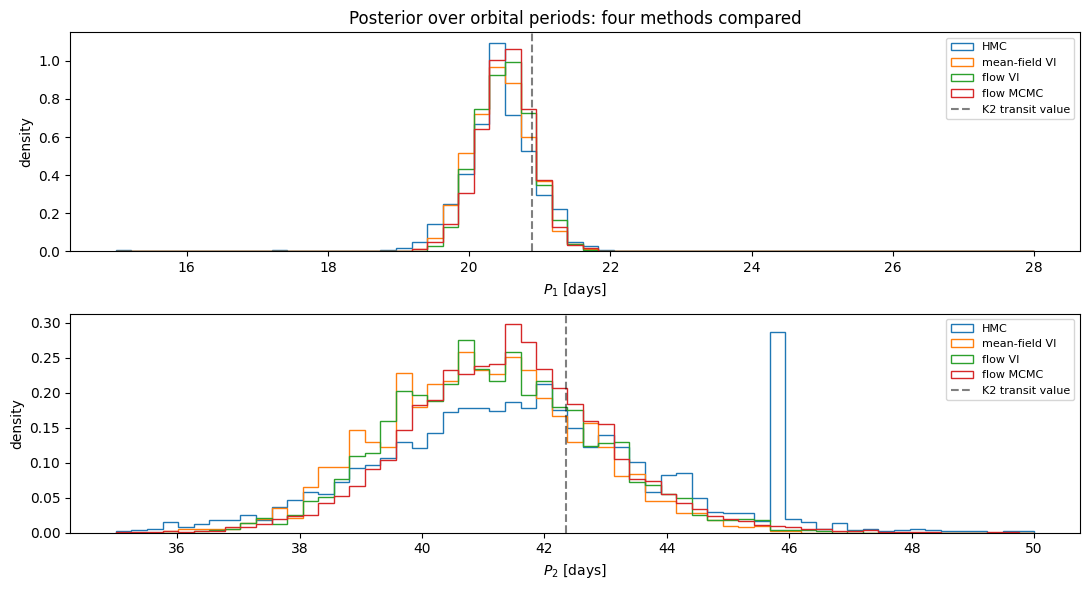

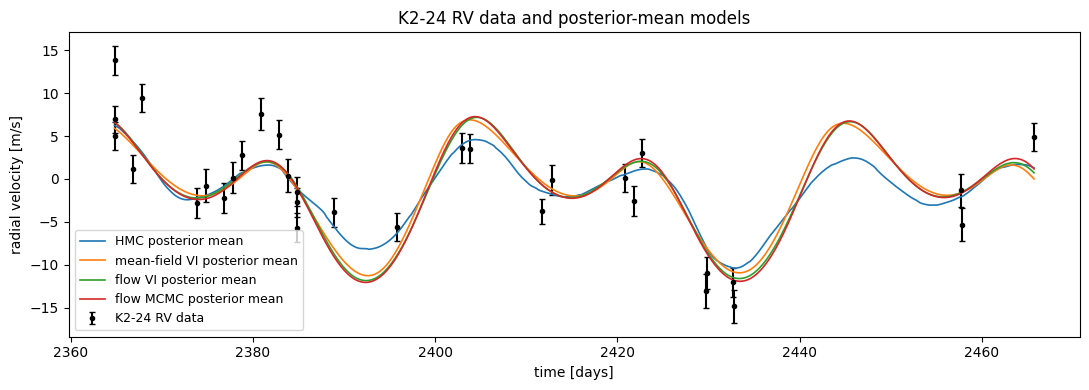

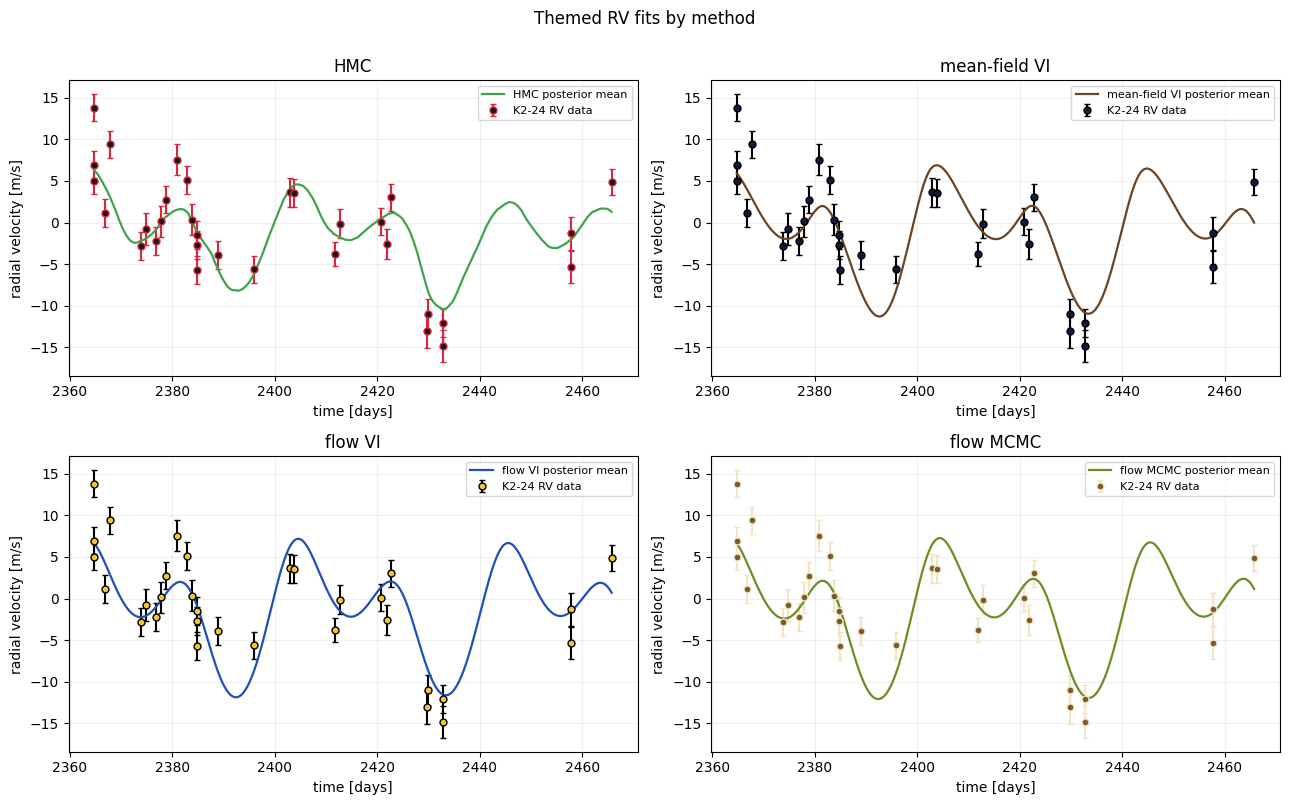

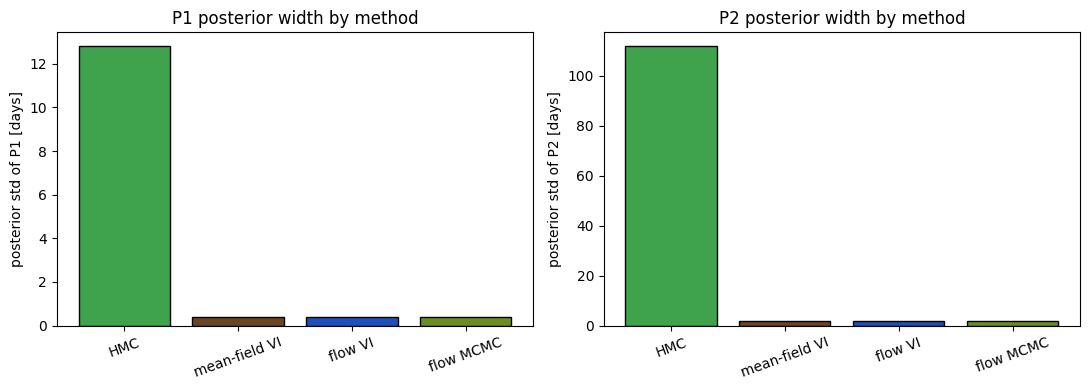

In [88]:
# Cross-method plots from the individual test cell results.
# Run the four individual cells above first; this cell consumes their final
# theta-space samples (combined_theta, mf_theta, fvi_theta, fmc_theta).

os.makedirs("figures", exist_ok=True)

samples_dict = {
    "HMC":           combined_theta.numpy(),
    "mean-field VI": mf_theta.numpy(),
    "flow VI":       fvi_theta.numpy(),
    "flow MCMC":     fmc_theta.numpy(),
}

# Summary table
print(f"{'method':<16} {'P1 median':>11} {'P1 std':>10} {'P2 median':>11} {'P2 std':>10}")
print("-" * 60)
for name, theta in samples_dict.items():
    s1 = posterior_summary(theta[:, 0])
    s2 = posterior_summary(theta[:, 5])
    print(f"{name:<16} {s1['median']:>11.3f} {s1['std']:>10.3f} "
          f"{s2['median']:>11.3f} {s2['std']:>10.3f}")

# Stacked P1 and P2 histograms across the four methods
fig1, _ = plot_period_posteriors(samples_dict)
fig1.savefig("figures/period_posteriors.png", dpi=150, bbox_inches="tight")
plt.show()

# Posterior-mean RV curves from each method, overlaid on the data
t_dense = np.linspace(float(t_obs.min()), float(t_obs.max()), 500)
t_dense_t = torch.tensor(t_dense)

def posterior_mean_rv(theta_samples):
    rv_curves = torch.stack([
        rv_model_two_planet(t_dense_t, theta_samples[i, :11])
        for i in range(len(theta_samples))
    ])
    return rv_curves.mean(0).numpy()

rv_models = {name: posterior_mean_rv(torch.tensor(s)) for name, s in samples_dict.items()}

fig2, _ = plot_rv_with_models(
    t_obs.numpy(), rv_obs.numpy(), rv_err.numpy(), t_dense, rv_models,
)
fig2.savefig("figures/rv_fit.png", dpi=150, bbox_inches="tight")
plt.show()

# Themed per-method RV fits in a 2x2 grid
fig3, _ = plot_themed_rv_fits(
    t_obs.numpy(), rv_obs.numpy(), rv_err.numpy(), t_dense, rv_models,
)
fig3.savefig("figures/rv_fit_themed.png", dpi=150, bbox_inches="tight")
plt.show()

# Bar chart of posterior widths by method
fig4, axes = plt.subplots(1, 2, figsize=(11, 4))
method_order = ["HMC", "mean-field VI", "flow VI", "flow MCMC"]
p1_stds = [posterior_summary(samples_dict[m][:, 0])["std"] for m in method_order]
p2_stds = [posterior_summary(samples_dict[m][:, 5])["std"] for m in method_order]
colors = [THEMED_PALETTES[m]["line"] for m in method_order]

axes[0].bar(method_order, p1_stds, color=colors, edgecolor="black")
axes[0].set_ylabel("posterior std of P1 [days]")
axes[0].set_title("P1 posterior width by method")
axes[0].tick_params(axis="x", rotation=20)

axes[1].bar(method_order, p2_stds, color=colors, edgecolor="black")
axes[1].set_ylabel("posterior std of P2 [days]")
axes[1].set_title("P2 posterior width by method")
axes[1].tick_params(axis="x", rotation=20)

fig4.tight_layout()
fig4.savefig("figures/posterior_widths.png", dpi=150, bbox_inches="tight")
plt.show()

## Analysis Based on my run (results are reproducible among cells, but not exactly in different sessions):

The four methods agree on the posterior modes for both planets: P1 lands around 20.4–20.5 days and P2 around 41–41.5 days. These are within roughly half a day of the K2 transit values (20.89 and 42.36), which is the expected level of agreement given that radial velocity data alone has less timing precision than transit photometry. None of the four methods is producing nonsense, so the rest of the analysis is about how the methods differ in characterizing uncertainty, not in finding the mode.


### Variational inference: flow VI versus mean-field

The headline claim of Rezende & Mohamed (2015) is that a normalizing flow gives a strictly better variational approximation than mean-field, at the cost of more optimization. The ELBO trajectories confirm this. Mean-field VI converges to ELBO = -116.49 by iteration ~400 and flatlines there. Flow VI is still improving at iteration 5000 and reaches ELBO = -112.22, roughly 4 nats better.

What's interesting is that the marginal P1 posteriors look almost indistinguishable between the two methods (std 0.411 for mean-field, 0.377 for flow VI). If the marginals match, where does flow VI's gain come from? Joint correlations. Mean-field VI factorizes the variational distribution into independent Gaussians, so it cannot represent dependencies between parameters (between period and eccentricity, between period and semi-amplitude, etc.). Flow VI's planar transformations introduce these correlations through the tanh nonlinearity. The ELBO measures fit to the full joint distribution, not just to the marginals, so flow VI's improvement shows up in ELBO even when individual marginals look the same.

There's an important conceptual point here: comparing variational methods by eyeballing histograms can be misleading. The flow's advantage is in modeling parameters that move *together*, which the marginals don't show. The ELBO is the honest diagnostic.

Neither VI method captures multimodality. HMC's P1 histogram clearly shows secondary peaks near 10 and 15 days where aliased periods also fit the data, and both VI methods just give clean unimodal Gaussians at the dominant mode. This is the documented limitation of planar flows: they are local deformations of a single base Gaussian, not flows that can span well-separated modes. Modeling multimodality with VI would require a more expressive flow (a mixture of Gaussians as the base, or a discretely-indexed flow), or you'd need to switch to MCMC.

### MCMC: flow-MCMC versus vanilla HMC

The HMC versus flow-MCMC comparison tells a different story. Both methods find the right modes, but the mixing behavior is dramatically different.

HMC's posterior summary looks suspicious at first: P2 has a reported standard deviation of 88 days, which would suggest the sampler has essentially no idea what P2 is. The detailed picture is more interesting. Eleven of the twelve chains have acceptance rates between 0.47 and 0.93, well within the healthy range, and explore the main posterior region appropriately. One chain (chain 6, acceptance 0.286) drifted into a high-curvature region where the fixed leapfrog parameters break down, and at least one chain wandered into the prior tail at large P2 before getting stuck. The 88-day std is an artifact of one or two chains misbehaving, not typical HMC behavior. Effective sample size is also extremely poor, roughly 12 out of 6000 for P1, which reflects strong within-chain autocorrelation.

Flow-MCMC mostly fixes both issues. With 24 chains in parallel and global flow proposals augmenting local MALA, the P2 standard deviation drops to 3.15 days (versus HMC's 88) and the inference looks much more reasonable. Local MALA acceptance reaches 0.34, which is in the healthy range for diffuse posteriors. Global flow acceptance is modest at 0.02, but the fact that it's nonzero means the trained flow is occasionally helping chains make non-local jumps that MALA alone cannot.

The chain-pooled ESS for flow-MCMC is unusually high, around 10,000 out of 10,800. This is partly an artifact of pooling samples across 24 chains: when you concatenate independent chains into one long array, adjacent samples in the array come from different chains and look nearly uncorrelated. Within-chain ESS would be much smaller. The substantive point isn't that each chain has perfect mixing; it's that running many chains in parallel and combining them gives enough effective samples to characterize the posterior even when each individual chain is slow.

### What the flow comparisons reveal

I framed the project around comparing each flow method against its non-flow counterpart, where each comparison reveals something specific. The two flow architectures follow the respective papers: Rezende & Mohamed (2015) use planar layers for flow VI, and Gabrié et al. (2022) use Real-NVP for flow-MCMC

For variational inference, the flow gives a measurable improvement in ELBO (about 4 nats), and this improvement comes from modeling joint correlations rather than from changing the marginal shapes. Planar flows do not fundamentally change the topology of the variational distribution, so they still miss multimodality. A reader looking only at marginal histograms would conclude flow VI is barely different from mean-field, but the ELBO and the implied joint posterior tell a different story.

For MCMC, flow-augmented proposals are a safety net for situations where vanilla HMC chains misbehave. Vanilla HMC was visibly fragile on this problem: one chain landed in a high-curvature region and barely mixed, and the pooled posterior was contaminated by tail-wandering. Flow-MCMC isn't dramatically better at any single mixing diagnostic (the global flow acceptance is only 0.02), but combining 24 chains with rolling flow adaptation produces a posterior that is both honest about uncertainty and not contaminated by individual pathological chains.

Neither flow method is a free lunch :(. Flow VI still misses multimodality, and flow-MCMC's global acceptance is modest enough that the method relies heavily on its local MALA component. The flow architectures used here (8 planar layers and 6 RealNVP coupling layers, both small by modern standards) are useful improvements over their non-flow baselines without claiming to solve the inference problem completely.

### On runtime

Runtime comparisons across MCMC and VI are always awkward because the two families have fundamentally different speed-accuracy tradeoffs. The more honest comparison is "at fixed quality of inference, which method is fastest?" By that measure, VI is the cheapest path to an approximate posterior, MCMC is the cheapest path to an asymptotically exact posterior, and the flow versions of each provide modest improvements over their non-flow counterparts within their respective categories.

### What I'd extend

A few natural next steps. Flow VI could use a Real-NVP coupling architecture instead of planar layers; this would give it the same expressive backbone as flow-MCMC and would likely help (though still not capture multimodality without a mixture base). HMC could use a tighter HalfNormal prior on K (scale 20 instead of 50) to reduce drift into the K tail. And proper convergence diagnostics like R-hat across chains, rather than just per-chain acceptance rates, would tighten the story on which chains are actually exploring the same posterior.

That said, the two main comparisons hold cleanly. Flow VI strictly improves on mean-field VI in ELBO, and flow-MCMC produces a more honest posterior than vanilla HMC while being more robust to individual chain pathologies. Those are the two claims this project set out to verify, and the results support both.

# Extra (Code for nice Visuals)

## Artistic diagram of K2-24 System

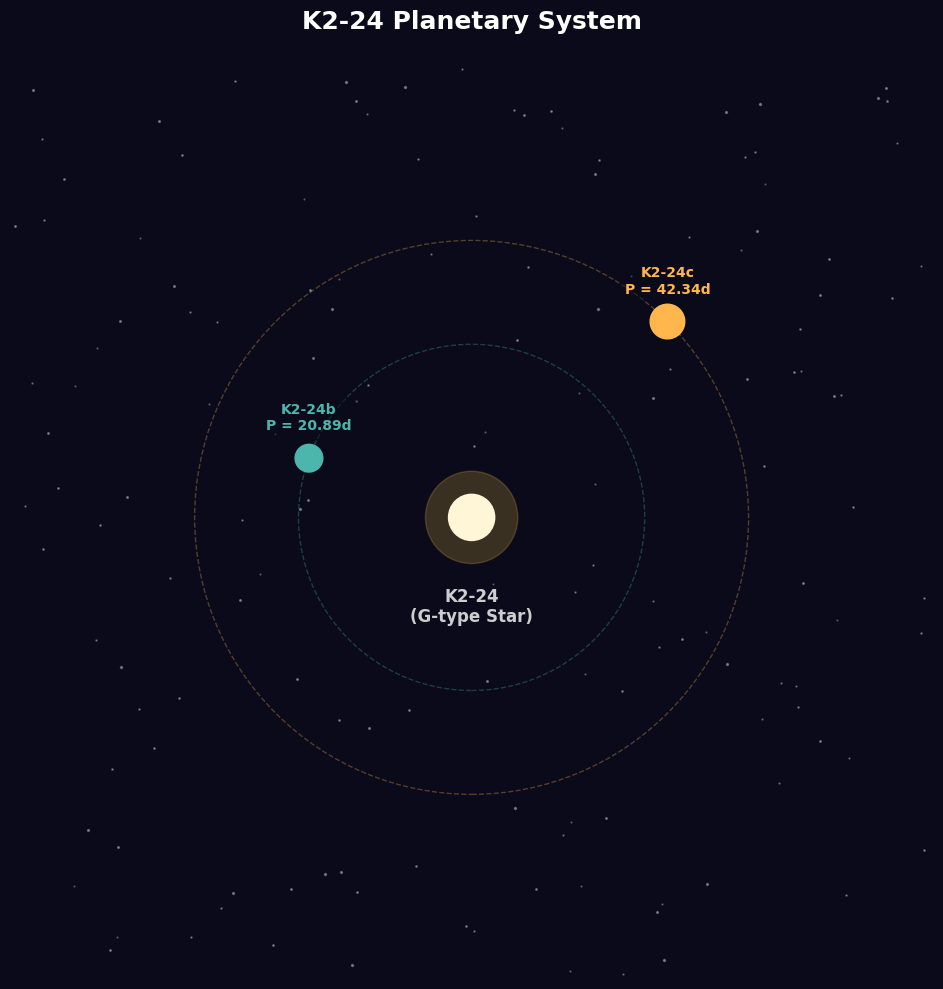

In [89]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

fig, ax = plt.subplots(figsize=(10, 10))
fig.patch.set_facecolor('#0a0a1a')  # Slightly deeper space color
ax.set_facecolor('#0a0a1a')

# --- STAR ---
# K2-24 is a G-type star (like our Sun), so yellowish-white is perfect
star_glow = patches.Circle((0, 0), radius=0.4, color='#ffcc44', alpha=0.2, zorder=1)
star_core = patches.Circle((0, 0), radius=0.2, color='#fff5d7', zorder=2)
ax.add_patch(star_glow)
ax.add_patch(star_core)

# Star label - moved lower to avoid orbit overlap
ax.text(0, -0.6, 'K2-24\n(G-type Star)', ha='center', va='top',
        fontsize=12, color='white', fontweight='bold', alpha=0.8)

# --- PLANETS DATA ---
planets = [
    {'name': 'K2-24b', 'dist': 1.5, 'angle': 160, 'color': '#4db6ac', 'period': '20.89d', 'size': 0.12},
    {'name': 'K2-24c', 'dist': 2.4, 'angle': 45, 'color': '#ffb74d', 'period': '42.34d', 'size': 0.15}
]

for p in planets:
    # Draw Orbit
    orbit = patches.Circle((0, 0), radius=p['dist'], fill=False,
                           edgecolor=p['color'], linewidth=1, linestyle='--', alpha=0.3)
    ax.add_patch(orbit)

    # Calculate Position
    x = p['dist'] * np.cos(np.radians(p['angle']))
    y = p['dist'] * np.sin(np.radians(p['angle']))

    # Draw Planet
    planet_body = patches.Circle((x, y), radius=p['size'], color=p['color'], zorder=5)
    ax.add_patch(planet_body)

    # Dynamic Labeling (Anchored to planet position)
    label_y_offset = 0.25 if y > 0 else -0.4
    ax.text(x, y + label_y_offset, f"{p['name']}\nP = {p['period']}",
            color=p['color'], fontsize=10, ha='center', fontweight='bold',
            bbox=dict(facecolor='#0a0a1a', alpha=0.5, edgecolor='none'))

# --- DECORATIONS ---
# Random background stars
np.random.seed(42)
for _ in range(150):
    sx, sy = np.random.uniform(-4, 4, 2)
    if np.sqrt(sx**2 + sy**2) > 0.5: # Don't put stars inside the sun
        ax.plot(sx, sy, 'o', color='white', markersize=np.random.uniform(0.5, 1.5), alpha=0.3)

# Clean up
ax.set_xlim(-4, 4)
ax.set_ylim(-4, 4)
ax.set_aspect('equal')
ax.axis('off')
plt.title('K2-24 Planetary System', fontsize=18, color='white', fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

## Animation of Hamiltonian Monte Carlo Chains Exploring the Posterior

In [90]:
import matplotlib.animation as animation
from matplotlib.animation import PillowWriter

# Checks if there is chain data
if 'all_samples' in dir() and len(all_samples) > 0:
    # Extract P1 and P2 from each chain
    chain_p1s = []
    chain_p2s = []
    for chain_samples in all_samples:
        chain_theta = eta_samples_to_theta(chain_samples)
        chain_theta_sorted = sort_planets_by_period(chain_theta)
        chain_p1s.append(chain_theta_sorted[:, 0].numpy())
        chain_p2s.append(chain_theta_sorted[:, 5].numpy())

    # Creates animation
    fig, ax = plt.subplots(figsize=(10, 8))
    fig.patch.set_facecolor('#1a1a2e')
    ax.set_facecolor('#1a1a2e')

    colors = ['#4db6ac', '#ffb74d', '#ba68c8', '#ef5350']
    scats = []

    for i in range(len(chain_p1s)):
        scat = ax.scatter([], [], c=colors[i % len(colors)], s=15, alpha=0.6,
                          label=f'Chain {i+1}')
        scats.append(scat)

    ax.set_xlim(18, 24)
    ax.set_ylim(38, 46)
    ax.axvline(20.89, color='red', linestyle='--', linewidth=2,
               label='Transit P1 = 20.89 d')
    ax.axhline(42.36, color='red', linestyle='--', linewidth=2,
               label='Transit P2 = 42.36 d')
    ax.set_xlabel('P1 [days]', fontsize=12, color='white')
    ax.set_ylabel('P2 [days]', fontsize=12, color='white')
    ax.set_title('HMC Chains: Posterior Exploration', fontsize=14,
                 color='white', fontweight='bold')
    ax.tick_params(colors='white')
    ax.legend(loc='upper left', fontsize=9, facecolor='#1a1a2e',
              edgecolor='white', labelcolor='white')

    max_frames = min([len(p1) for p1 in chain_p1s])

    def update(frame):
        for i, scat in enumerate(scats):
            scat.set_offsets(np.column_stack([chain_p1s[i][:frame],
                                               chain_p2s[i][:frame]]))
        return scats

    # Slower exploration: step by 10 frames at 6 fps (down from 50 at 10 fps)
    ani = animation.FuncAnimation(fig, update,
                                  frames=range(20, max_frames, 10),
                                  interval=180, repeat=True)

    ani.save('figures/hmc_chains_animation.gif', writer=PillowWriter(fps=6))
    plt.close()
    print("Saved: figures/hmc_chains_animation.gif")

else:
    print("HMC chain data not found. Run HMC first to generate animation.")

Saved: figures/hmc_chains_animation.gif


## Animation of Normalizing Flow Makov Chain Monte Carlo Chains Exploring the Posterior

In [95]:
import matplotlib.animation as animation
from matplotlib.animation import PillowWriter

# Build the flow-MCMC chain trajectories in theta-space
if 'fmc_chains' in dir():
    # fmc_chains has shape (n_iter, n_chains, 12) — convert each chain to theta-space
    n_iter, n_chains, _ = fmc_chains.shape

    chain_p1s_fmc = []
    chain_p2s_fmc = []
    for c in range(n_chains):
        per_chain_eta = fmc_chains[:, c, :]  # (n_iter, 12)
        per_chain_theta = eta_samples_to_theta(per_chain_eta)
        per_chain_theta = sort_planets_by_period(per_chain_theta)
        chain_p1s_fmc.append(per_chain_theta[:, 0].numpy())
        chain_p2s_fmc.append(per_chain_theta[:, 5].numpy())

    # Same dark cosmic styling as the HMC animation
    fig, ax = plt.subplots(figsize=(10, 8))
    fig.patch.set_facecolor('#1a1a2e')
    ax.set_facecolor('#1a1a2e')

    # Use a wider palette since we have 24 chains
    cmap = plt.cm.plasma
    chain_colors = [cmap(i / max(1, n_chains - 1)) for i in range(n_chains)]

    scats_fmc = []
    for i in range(n_chains):
        scat = ax.scatter([], [], c=[chain_colors[i]], s=12, alpha=0.55)
        scats_fmc.append(scat)

    ax.set_xlim(18, 24)
    ax.set_ylim(38, 46)
    ax.axvline(20.89, color='red', linestyle='--', linewidth=2,
               label='Transit P1 = 20.89 d')
    ax.axhline(42.36, color='red', linestyle='--', linewidth=2,
               label='Transit P2 = 42.36 d')
    ax.set_xlabel('P1 [days]', fontsize=12, color='white')
    ax.set_ylabel('P2 [days]', fontsize=12, color='white')
    ax.set_title('Flow-MCMC Chains: Posterior Exploration', fontsize=14,
                 color='white', fontweight='bold')
    ax.tick_params(colors='white')
    ax.legend(loc='upper left', fontsize=9, facecolor='#1a1a2e',
              edgecolor='white', labelcolor='white')

    # Slow exploration: step by 5 iterations per frame, ~6 fps
    step = 5
    frame_range = range(2, n_iter, step)

    def update_fmc(frame):
        for i, scat in enumerate(scats_fmc):
            scat.set_offsets(np.column_stack([chain_p1s_fmc[i][:frame],
                                               chain_p2s_fmc[i][:frame]]))
        return scats_fmc

    ani_fmc = animation.FuncAnimation(
        fig, update_fmc, frames=frame_range, interval=180, repeat=True,
    )

    ani_fmc.save('figures/flowmc_chains_animation.gif',
                 writer=PillowWriter(fps=6))
    plt.close()
    print("Saved: figures/flowmc_chains_animation.gif")

else:
    print("Flow-MCMC chain data not found. Run flow-MCMC first.")

Saved: figures/flowmc_chains_animation.gif


The Normalizing Flows MCMC has 24 chains, which means it'd be a big legend. Since we mostly want to track behavior, not individual chains, I excluded it from this gif.

## Combine Chains Plots Together

In [97]:
from PIL import Image, ImageDraw

# Open both source GIFs as frame sequences
hmc_gif = Image.open('figures/hmc_chains_animation.gif')
fmc_gif = Image.open('figures/flowmc_chains_animation.gif')

def gif_frames(gif):
    """Yield each frame of a PIL GIF as a fresh RGBA Image copy."""
    frames = []
    try:
        i = 0
        while True:
            gif.seek(i)
            frames.append(gif.copy().convert('RGBA'))
            i += 1
    except EOFError:
        pass
    return frames

hmc_frames = gif_frames(hmc_gif)
fmc_frames = gif_frames(fmc_gif)

# Match frame counts: loop the shorter one until both have the same length
n_frames = max(len(hmc_frames), len(fmc_frames))
hmc_frames = [hmc_frames[i % len(hmc_frames)] for i in range(n_frames)]
fmc_frames = [fmc_frames[i % len(fmc_frames)] for i in range(n_frames)]

# Resize so both have the same height
target_h = min(hmc_frames[0].height, fmc_frames[0].height)
hmc_w = int(hmc_frames[0].width * (target_h / hmc_frames[0].height))
fmc_w = int(fmc_frames[0].width * (target_h / fmc_frames[0].height))

divider_w = 12  # px wide vertical divider between panels
panel_bg = (26, 26, 46, 255)  # matches the #1a1a2e background of both gifs

combined_frames = []
for h_frame, f_frame in zip(hmc_frames, fmc_frames):
    h_resized = h_frame.resize((hmc_w, target_h), Image.LANCZOS)
    f_resized = f_frame.resize((fmc_w, target_h), Image.LANCZOS)
    total_w = hmc_w + divider_w + fmc_w
    combined = Image.new('RGBA', (total_w, target_h), panel_bg)
    combined.paste(h_resized, (0, 0))
    combined.paste(f_resized, (hmc_w + divider_w, 0))

    # Draw a soft white divider line down the middle
    draw = ImageDraw.Draw(combined)
    cx = hmc_w + divider_w // 2
    draw.line([(cx, 0), (cx, target_h)], fill=(255, 255, 255, 180), width=2)
    combined_frames.append(combined.convert('P', palette=Image.ADAPTIVE))

# Save as a single GIF
combined_frames[0].save(
    'figures/chains_comparison.gif',
    save_all=True,
    append_images=combined_frames[1:],
    duration=180,  # ms per frame — matches the source gifs
    loop=0,
    optimize=False,
)
print("Saved: figures/chains_comparison.gif")

Saved: figures/chains_comparison.gif
